In [1]:
import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.utils import to_categorical, Sequence
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance  # Import PIL for image enhancement
import random  # For random augmentation factors

# 1. Define file paths
train_dir = 'train_set'
val_dir = 'validation_set'
test_dir = 'test_set'

# Define global parameters
point_radius = 5  
input_channels = 8  

# Crop images
def combine_data_and_images(image_R, image_T):
    left = 135
    upper = 13
    right = 740
    lower = 618
    # Use numpy slicing to crop
    cropped_image_R = image_R[upper:lower, left:right]
    cropped_image_T = image_T[upper:lower, left:right]
    return cropped_image_R, cropped_image_T

# Get all data paths in the dataset
def get_data_paths(data_dir):
    data_paths = []
    for root, dirs, files in os.walk(data_dir):
        # Convert filenames to lowercase for easier matching
        files_lower = [f.lower() for f in files]
        required_files = ['filtered_r_image.tif', 'filtered_t_image.tif', 'processed_data.csv']
        if all(f in files_lower for f in required_files):
            data_paths.append(root)
    return data_paths

# Normalize and scale x and y to the range 0-605
def transform_coordinates(data):
    # Find the minimum and maximum values of x and y
    x_min, x_max = data['x'].min(), data['x'].max()
    y_min, y_max = data['y'].min(), data['y'].max()

    # Normalize and scale to 0-605
    data['x_new'] = ((data['x'] - x_min) / (x_max - x_min)) * 605
    data['y_new'] = ((data['y'] - y_min) / (y_max - y_min)) * 605

    return data[['x_new', 'y_new']]

# Collect all categories in the training set
def collect_train_categories(train_paths):
    categories = set()
    for path in train_paths:
        csv_path = os.path.join(path, 'processed_data.csv')
        if os.path.exists(csv_path):
            data = pd.read_csv(csv_path)
            transformed = transform_coordinates(data)  # Apply coordinate transformation
            data[['x_new', 'y_new']] = transformed
            categories.update(data['Category'].unique())
        else:
            print(f"Warning: File not found {csv_path}")
    return sorted(list(categories))

# Get training, validation, and test data paths
train_paths = get_data_paths(train_dir)
val_paths = get_data_paths(val_dir)
test_paths = get_data_paths(test_dir)

# Check if the training set is empty
if not train_paths:
    raise ValueError("No training data found. Please check the training data directory and filenames.")
else:
    print(f"Found {len(train_paths)} training samples.")

if not val_paths:
    print("No validation data found. Please check the validation data directory and filenames.")
else:
    print(f"Found {len(val_paths)} validation samples.")

if not test_paths:
    print("No test data found. Please check the test data directory and filenames.")
else:
    print(f"Found {len(test_paths)} test samples.")

# Collect all categories in the training set
train_categories = collect_train_categories(train_paths)
print(f"Categories in the training set: {train_categories}")

# Train OneHotEncoder
encoder = OneHotEncoder(sparse=False, handle_unknown='ignore')
# Fit on a NumPy array without feature names to avoid warnings
encoder.fit(np.array(train_categories).reshape(-1, 1))
num_classes = len(encoder.categories_[0]) + 1  # Add 1 to include background
print(f"Number of classes (including background): {num_classes}")

# Define image enhancement function
def enhance_contrast_and_brightness(img, contrast_factor=2.0, brightness_factor=2.5):
    """
    Enhance the contrast and brightness of an image using PIL.

    Parameters:
        img (numpy.ndarray): Input image in BGR format.
        contrast_factor (float): Factor by which to adjust the contrast.
        brightness_factor (float): Factor by which to adjust the brightness.

    Returns:
        numpy.ndarray: Enhanced image in BGR format.
    """
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert to PIL image
    brightness_enhancer = ImageEnhance.Brightness(img_pil)
    brightened_img = brightness_enhancer.enhance(brightness_factor)

    contrast_enhancer = ImageEnhance.Contrast(brightened_img)
    enhanced_img = contrast_enhancer.enhance(contrast_factor)

    return cv2.cvtColor(np.array(enhanced_img), cv2.COLOR_RGB2BGR)  # Convert back to OpenCV format

# Define data generator for batch loading and preprocessing
class DataGenerator(Sequence):
    def __init__(self, list_IDs, batch_size=8, shuffle=True, encoder=None, num_classes=None, augment=False):
        """
        Initialize data generator.

        Parameters:
            list_IDs (list): List of data subfolder paths.
            batch_size (int): Number of samples per batch.
            shuffle (bool): Whether to shuffle data after each epoch.
            encoder (OneHotEncoder): Pre-fitted OneHotEncoder.
            num_classes (int): Number of classes (including background).
            augment (bool): Whether to apply data augmentation.
        """
        self.list_IDs = list_IDs
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.encoder = encoder
        self.num_classes = num_classes
        self.augment = augment
        self.indexes = np.arange(len(self.list_IDs))
        self.on_epoch_end()

    # Return number of steps per epoch
    def __len__(self):
        return int(np.floor(len(self.list_IDs) / self.batch_size))
    
    # Generate one batch of data
    def __getitem__(self, index):
        # Generate indices of the current batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        # Get IDs for the current batch
        list_IDs_temp = [self.list_IDs[k] for k in indexes]
        # Generate data
        X, y = self.__data_generation(list_IDs_temp)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    # Generate batch data
    def __data_generation(self, list_IDs_temp):
        # Initialize
        X_batch = []
        y_batch = []
        for ID in list_IDs_temp:
            # Load and preprocess data
            X, y = load_and_preprocess_data(ID, self.encoder, self.num_classes, self.augment)
            X_batch.append(X)
            y_batch.append(y)
        # Convert to arrays
        X_batch = np.array(X_batch)
        y_batch = np.array(y_batch)
        return X_batch, y_batch

# Load images and label data, and preprocess
def load_and_preprocess_data(data_path, encoder, num_classes, augment=False):
    image_path_R = os.path.join(data_path, 'Filtered_R_Image.tif')
    image_path_T = os.path.join(data_path, 'Filtered_T_Image.tif')
    csv_path = os.path.join(data_path, 'processed_data.csv')

    # Load RGB images
    image_R = cv2.imread(image_path_R, cv2.IMREAD_COLOR)
    if image_R is None:
        raise ValueError(f"Cannot read image file: {image_path_R}")
    image_R = cv2.cvtColor(image_R, cv2.COLOR_BGR2RGB)

    image_T = cv2.imread(image_path_T, cv2.IMREAD_COLOR)
    if image_T is None:
        raise ValueError(f"Cannot read image file: {image_path_T}")
    image_T = cv2.cvtColor(image_T, cv2.COLOR_BGR2RGB)

    # Crop both images
    image_R, image_T = combine_data_and_images(image_R, image_T)

    # Apply image enhancement if augment is True
    if augment:
        # Randomize factors for more variability
        contrast = random.uniform(1.0, 2.0)  # Example: between 1.0 and 2.0
        brightness = random.uniform(1.0, 2.5)  # Example: between 1.0 and 2.5
        image_R = enhance_contrast_and_brightness(image_R, contrast, brightness)
        image_T = enhance_contrast_and_brightness(image_T, contrast, brightness)

    # Load CSV file
    if not os.path.exists(csv_path):
        raise ValueError(f"File not found: {csv_path}")
    data = pd.read_csv(csv_path)

    # Apply coordinate transformation
    transformed = transform_coordinates(data)
    data[['x_new', 'y_new']] = transformed

    # Get image dimensions
    height, width, _ = image_R.shape

    # Extract central circular region
    center_x, center_y = width // 2, height // 2
    radius = 605 // 2  

    Y, X_grid = np.ogrid[:height, :width]
    dist_from_center = np.sqrt((X_grid - center_x)**2 + (Y - center_y)**2)
    mask = dist_from_center <= radius

    # Apply mask to each channel
    masked_image_R = np.zeros_like(image_R)
    masked_image_R[mask] = image_R[mask]

    masked_image_T = np.zeros_like(image_T)
    masked_image_T[mask] = image_T[mask]

    # Process numerical variables 'Sn' and 'Ba'
    # Create two single-channel images, initialized to 0
    sn_image = np.zeros((height, width), dtype=np.float32)
    ba_image = np.zeros((height, width), dtype=np.float32)

    # Map data coordinates to image pixel coordinates
    data['x_pixel'] = data['x_new'].astype(int)
    data['y_pixel'] = data['y_new'].astype(int)
    data['x_pixel'] = data['x_pixel'].clip(0, width - 1)
    data['y_pixel'] = data['y_pixel'].clip(0, height - 1)

    # Fill 'Sn' and 'Ba' images
    for idx, row in data.iterrows():
        x = int(row['x_pixel'])  # Ensure x is integer
        y = int(row['y_pixel'])  # Ensure y is integer
        sn_image[y, x] = row['Sn']
        ba_image[y, x] = row['Ba']

    # Apply mask to 'Sn' and 'Ba' images
    masked_sn = np.zeros_like(sn_image)
    masked_sn[mask] = sn_image[mask]

    masked_ba = np.zeros_like(ba_image)
    masked_ba[mask] = ba_image[mask]

    # Normalize 'Sn' and 'Ba' images to [0, 255]
    max_sn = np.max(masked_sn)
    max_ba = np.max(masked_ba)
    masked_sn = (masked_sn / max_sn * 255).astype(np.uint8) if max_sn != 0 else masked_sn.astype(np.uint8)
    masked_ba = (masked_ba / max_ba * 255).astype(np.uint8) if max_ba != 0 else masked_ba.astype(np.uint8)

    # Adjust image size to multiples of 16
    new_height = (height // 16) * 16
    new_width = (width // 16) * 16
    masked_image_R = masked_image_R[:new_height, :new_width, :]
    masked_image_T = masked_image_T[:new_height, :new_width, :]
    masked_sn = masked_sn[:new_height, :new_width]
    masked_ba = masked_ba[:new_height, :new_width]
    height, width, _ = masked_image_R.shape  

    # Add 'Sn' and 'Ba' as additional channels
    sn_channel = np.expand_dims(masked_sn, axis=-1)
    ba_channel = np.expand_dims(masked_ba, axis=-1)
    input_image = np.concatenate([masked_image_R, masked_image_T, sn_channel, ba_channel], axis=-1)

    # Encode the 'Category' column
    # **Modification to resolve the warning: Use NumPy array without feature names**
    categories_encoded = encoder.transform(data['Category'].values.reshape(-1, 1))

    # Create target mask
    target_mask = np.zeros((height, width), dtype=np.uint8)

    for idx, row in data.iterrows():
        x = int(row['x_pixel'])  # Ensure x is integer
        y = int(row['y_pixel'])  # Ensure y is integer
        category_index = int(np.argmax(categories_encoded[idx]) + 1)  # Add 1 to avoid background being 0
        cv2.circle(target_mask, (x, y), point_radius, category_index, -1)

    # One-Hot encode the target mask
    target_mask_one_hot = to_categorical(target_mask, num_classes=num_classes)

    return input_image, target_mask_one_hot

# Create training, validation, and test data generators
train_generator = DataGenerator(
    train_paths, 
    batch_size=8,  # Changed batch size to 8
    shuffle=True, 
    encoder=encoder, 
    num_classes=num_classes, 
    augment=True  # Enable augmentation for training data
)

val_generator = DataGenerator(
    val_paths, 
    batch_size=8,  # Changed batch size to 8
    shuffle=False, 
    encoder=encoder, 
    num_classes=num_classes, 
    augment=False  # Disable augmentation for validation data
)

test_generator = DataGenerator(
    test_paths, 
    batch_size=8,  # Changed batch size to 8
    shuffle=False, 
    encoder=encoder, 
    num_classes=num_classes, 
    augment=False  # Disable augmentation for test data
)

# Define UNet model
def unet_model(input_size, num_classes):
    inputs = layers.Input(input_size)

    # Downsampling part
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2,2), padding='same')(c1)

    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2,2), padding='same')(c2)

    c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2,2), padding='same')(c3)

    c4 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2,2), padding='same')(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3,3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3,3), activation='relu', padding='same')(c5)

    # Upsampling part
    u6 = layers.UpSampling2D((2,2))(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3,3), activation='relu', padding='same')(c6)

    u7 = layers.UpSampling2D((2,2))(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3,3), activation='relu', padding='same')(c7)

    u8 = layers.UpSampling2D((2,2))(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(c8)

    u9 = layers.UpSampling2D((2,2))(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(num_classes, (1,1), activation='softmax')(c9)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Create model
sample_X, sample_y = train_generator[0]
input_height, input_width, _ = sample_X.shape[1:]
input_size = (input_height, input_width, input_channels)

model = unet_model(input_size=input_size, num_classes=num_classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define learning rate scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Monitor validation loss
    factor=0.5,            # When the monitored metric stops improving, reduce learning rate by half
    patience=3,            # Number of epochs with no improvement before reducing learning rate
    min_lr=1e-6            # Minimum learning rate
)

# Train the model with callbacks
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[reduce_lr]
)

# Save the trained model
model.save('unet_model.h5')


2024-11-19 00:50:14.240556: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Found 218 training samples.
Found 20 validation samples.
Found 40 test samples.
Categories in the training set: [1, 2, 3]
Number of classes (including background): 4


/root/miniconda3/lib/python3.8/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 592, 592, 8  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 592, 592, 64  4672        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 592, 592, 64  36928       ['conv2d[0][0]']                 
                                )                                                             

2024-11-19 00:50:24.037889: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-19 00:50:24.520467: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:1f:00.0, compute capability: 8.9


                                                                                                  
Total params: 31,382,020
Trainable params: 31,382,020
Non-trainable params: 0
__________________________________________________________________________________________________
Epoch 1/50


2024-11-19 00:50:38.973787: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2024-11-19 00:50:39.606076: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 8.9
2024-11-19 00:50:39.606092: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2024-11-19 00:50:39.606134: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


27/27 [==============================] - 188s 7s/step - loss: 56.2758 - accuracy: 0.5361 - val_loss: 0.7960 - val_accuracy: 0.6114 - lr: 0.0010
Epoch 2/50
27/27 [==============================] - 181s 7s/step - loss: 0.6874 - accuracy: 0.6654 - val_loss: 0.6608 - val_accuracy: 0.6637 - lr: 0.0010
Epoch 3/50
27/27 [==============================] - 180s 7s/step - loss: 0.6971 - accuracy: 0.6707 - val_loss: 0.7245 - val_accuracy: 0.6185 - lr: 0.0010
Epoch 4/50
27/27 [==============================] - 181s 7s/step - loss: 0.6464 - accuracy: 0.6839 - val_loss: 0.6816 - val_accuracy: 0.6801 - lr: 0.0010
Epoch 5/50
27/27 [==============================] - 180s 7s/step - loss: 0.6243 - accuracy: 0.7129 - val_loss: 0.6803 - val_accuracy: 0.6841 - lr: 0.0010
Epoch 6/50
27/27 [==============================] - 179s 7s/step - loss: 0.6144 - accuracy: 0.7180 - val_loss: 0.6442 - val_accuracy: 0.7066 - lr: 5.0000e-04
Epoch 7/50
27/27 [==============================] - 180s 7s/step - loss: 0.6305 - 

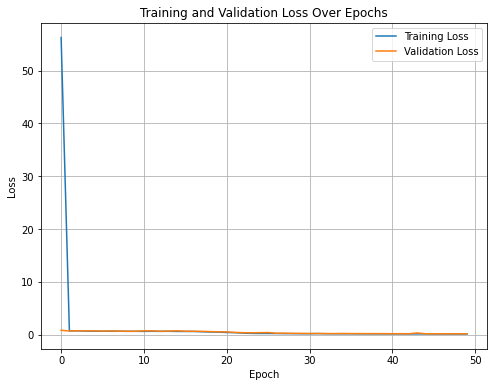

In [2]:
# Plot training and validation loss curves
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# (Optional) Save the loss curves as an image
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')  # Save as PNG file
plt.close()


5/5 [==============================] - 31s 6s/step - loss: 0.1448 - accuracy: 0.9443
Test Loss: 0.14484967291355133, Test Accuracy: 0.9442773461341858
1/1 [==============================] - 0s 34ms/step


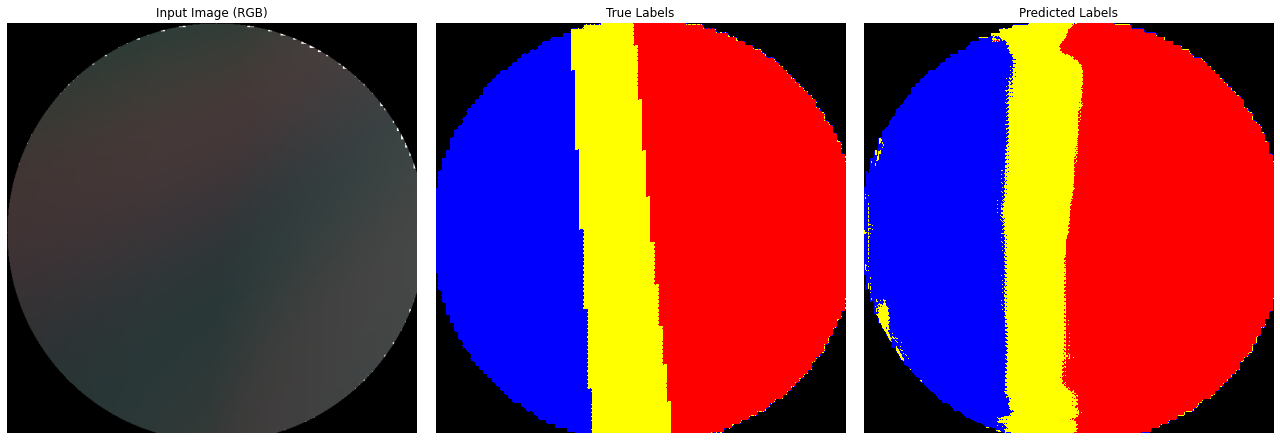

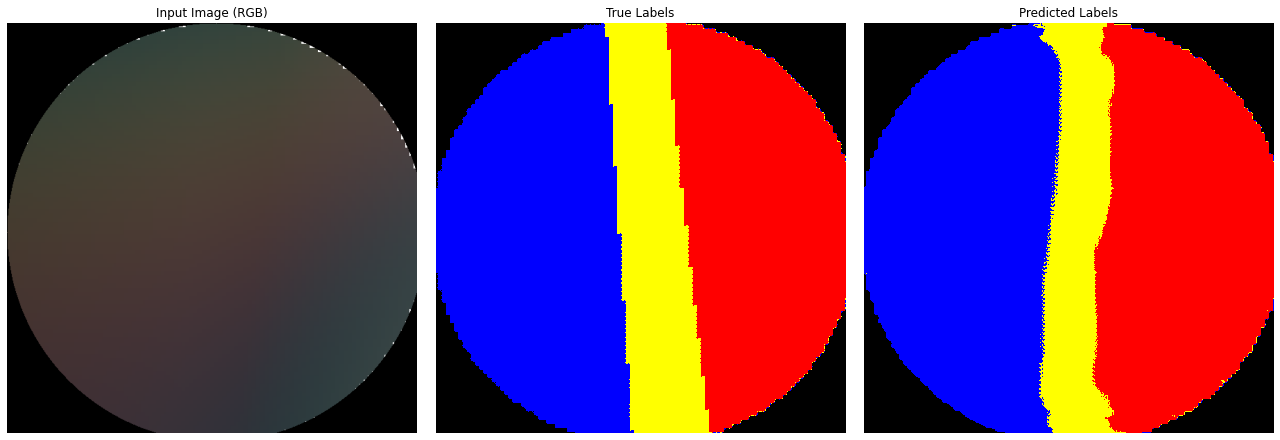

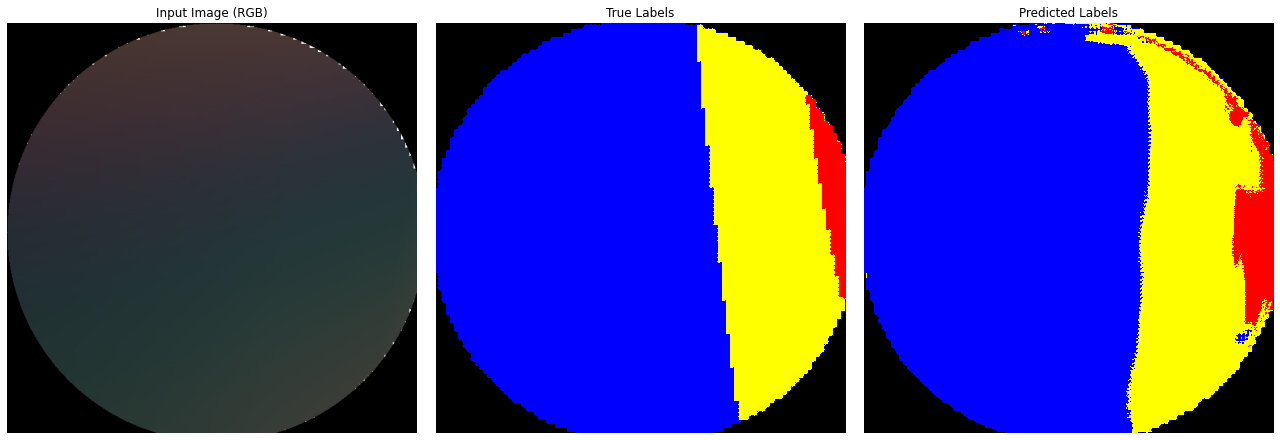

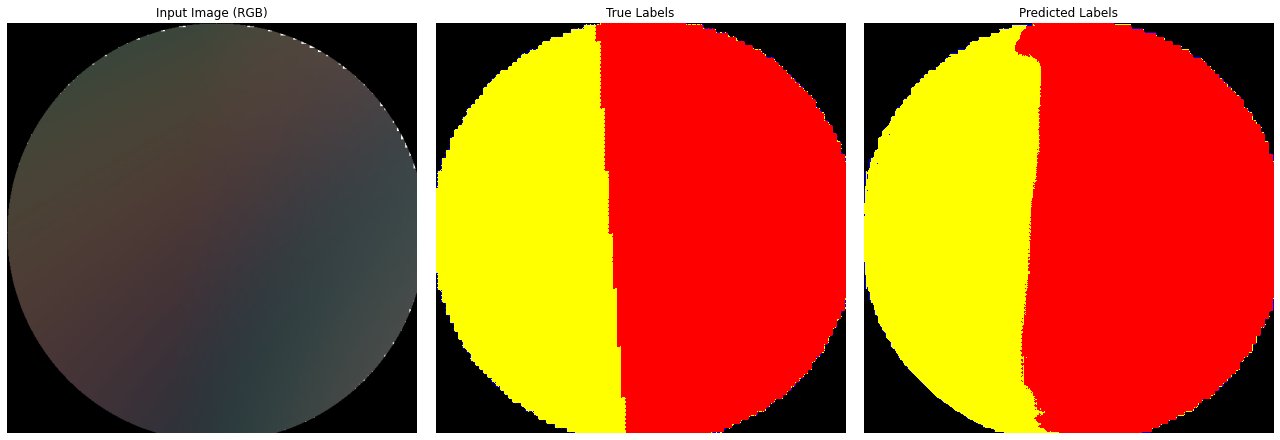

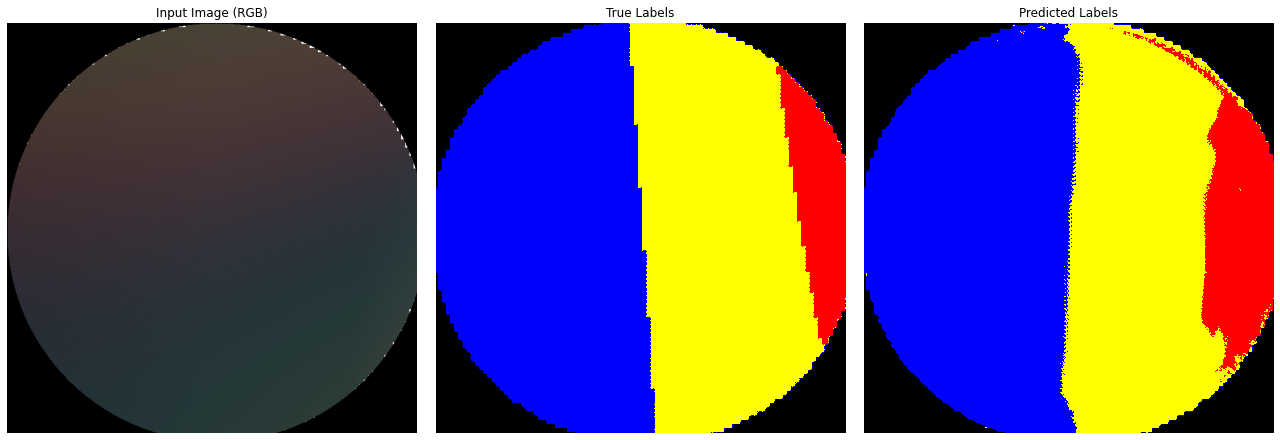

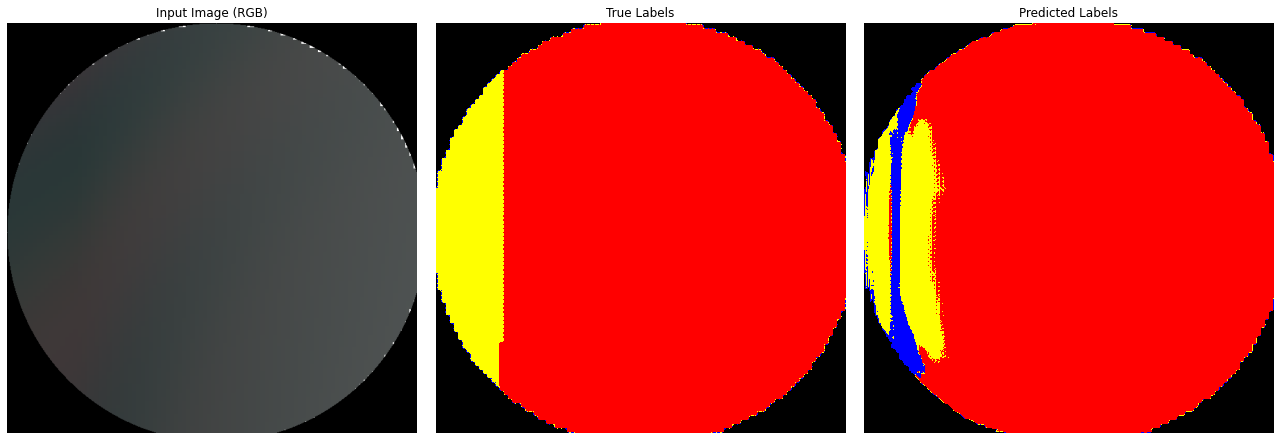

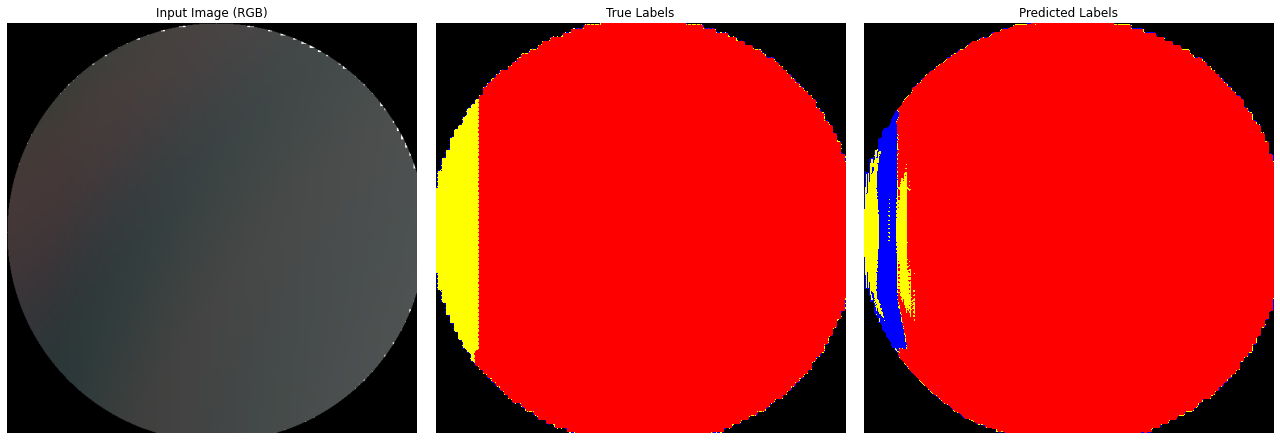

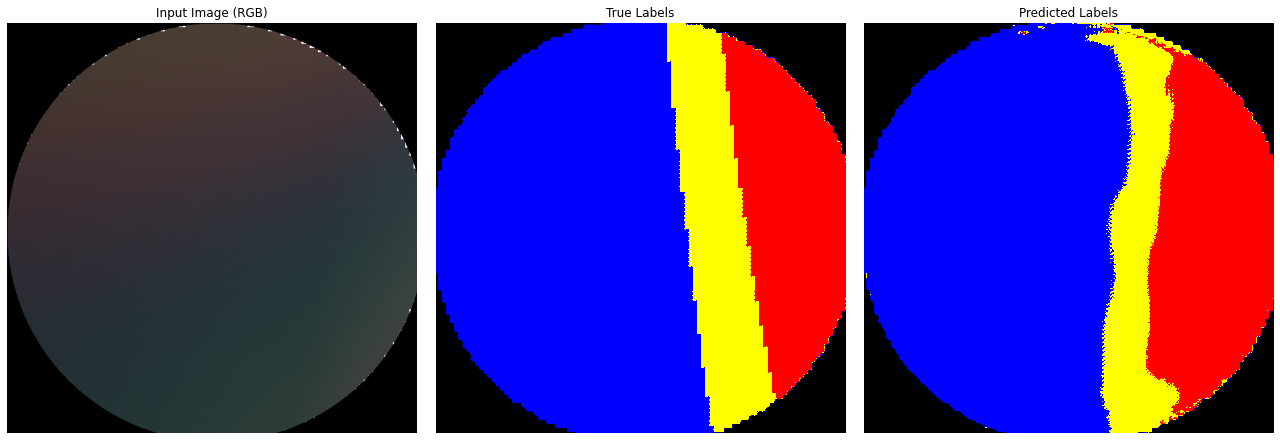

1/1 [==============================] - 0s 33ms/step


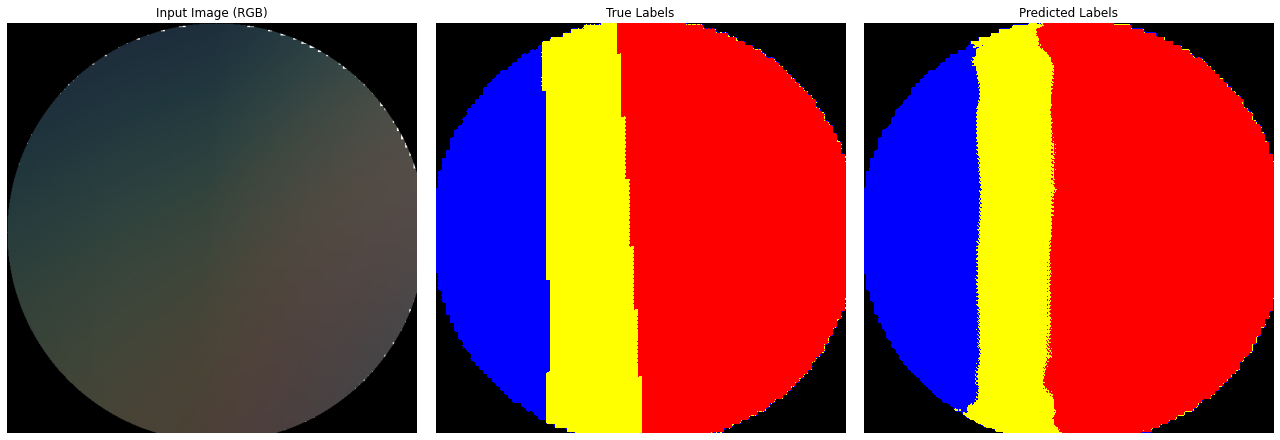

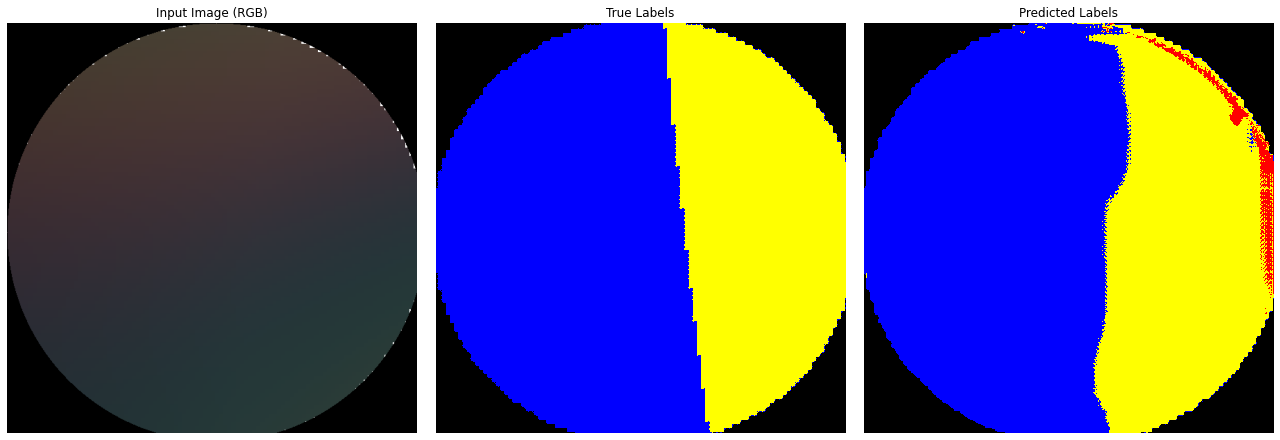

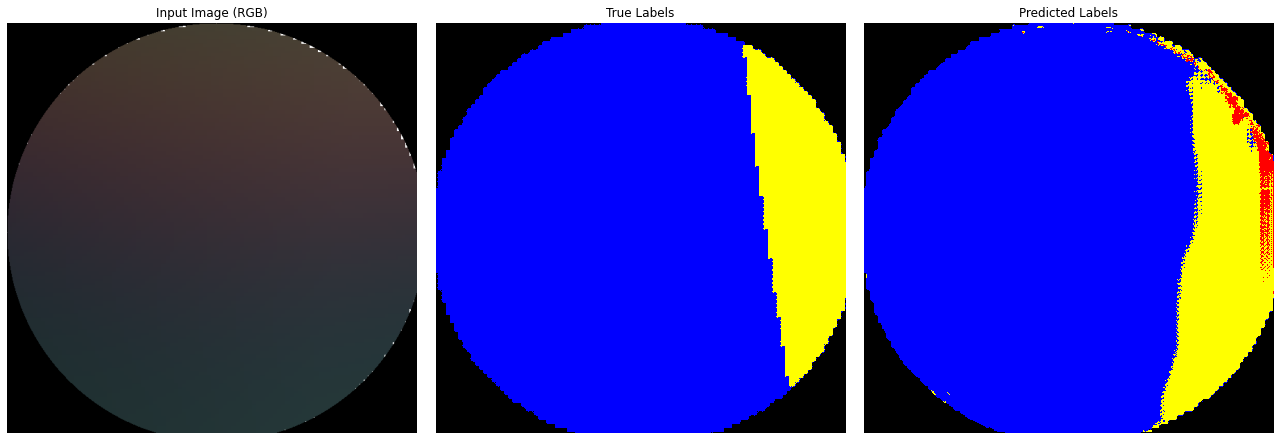

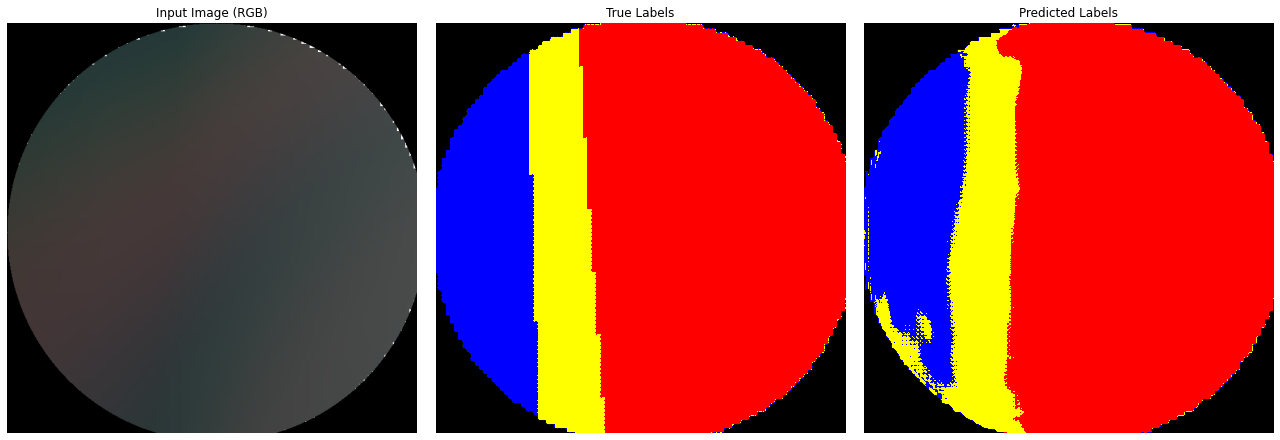

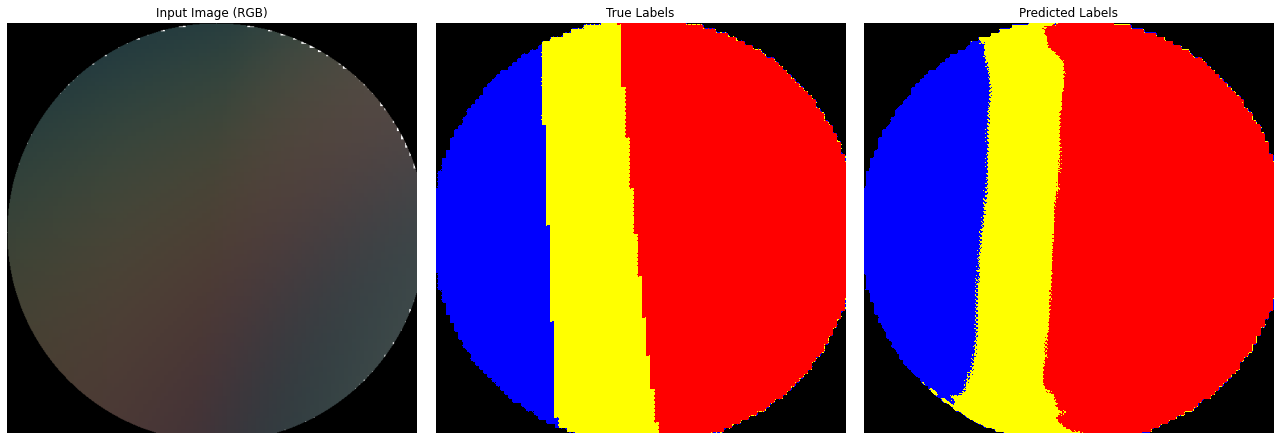

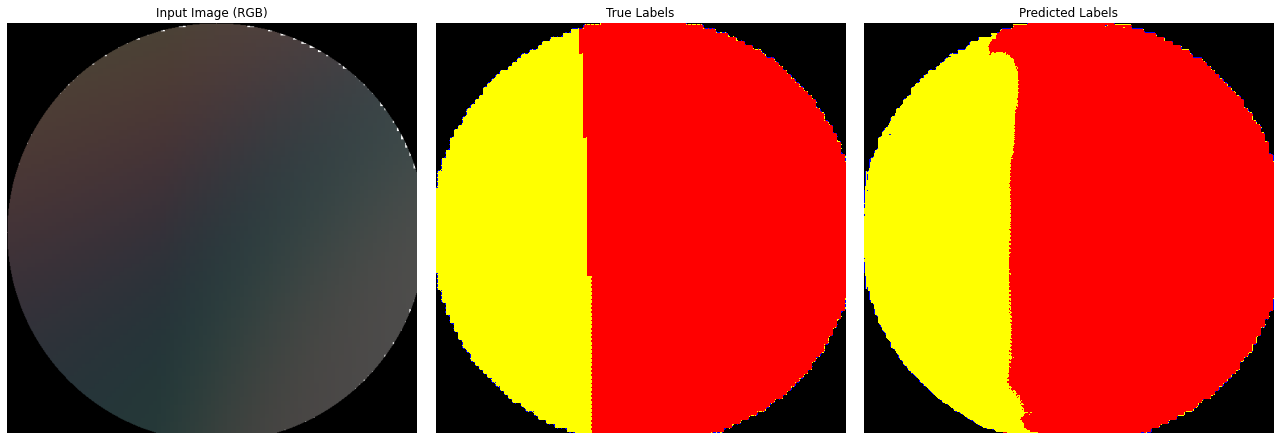

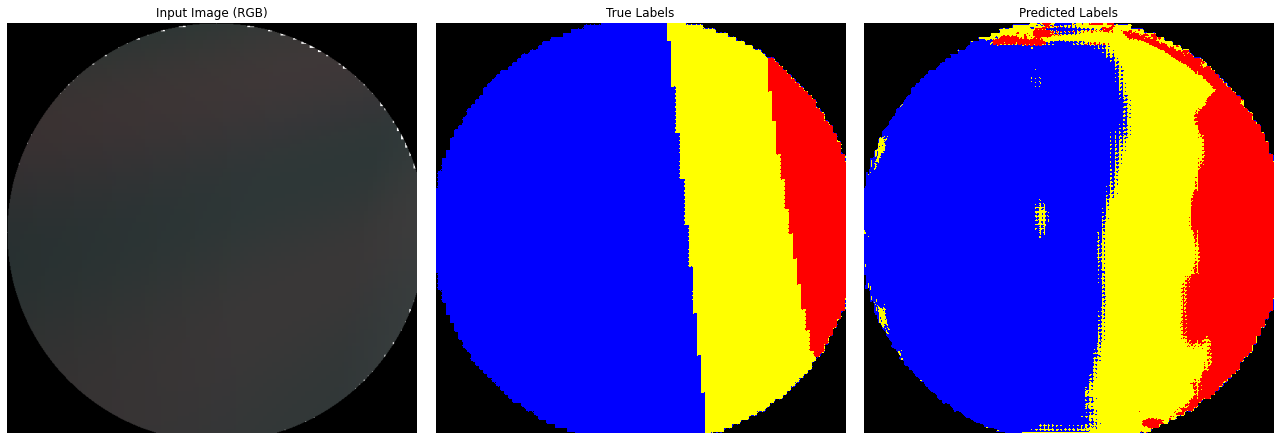

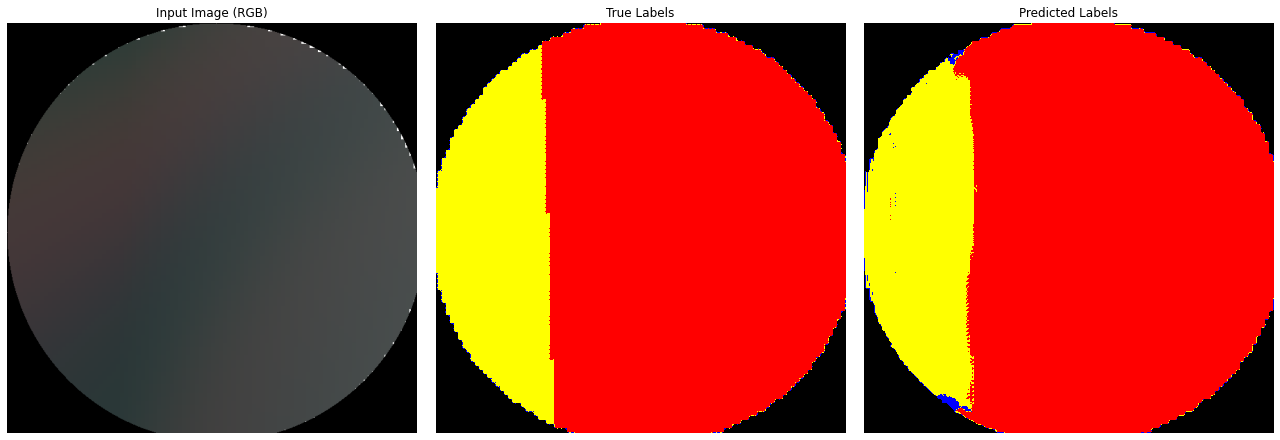

1/1 [==============================] - 0s 33ms/step


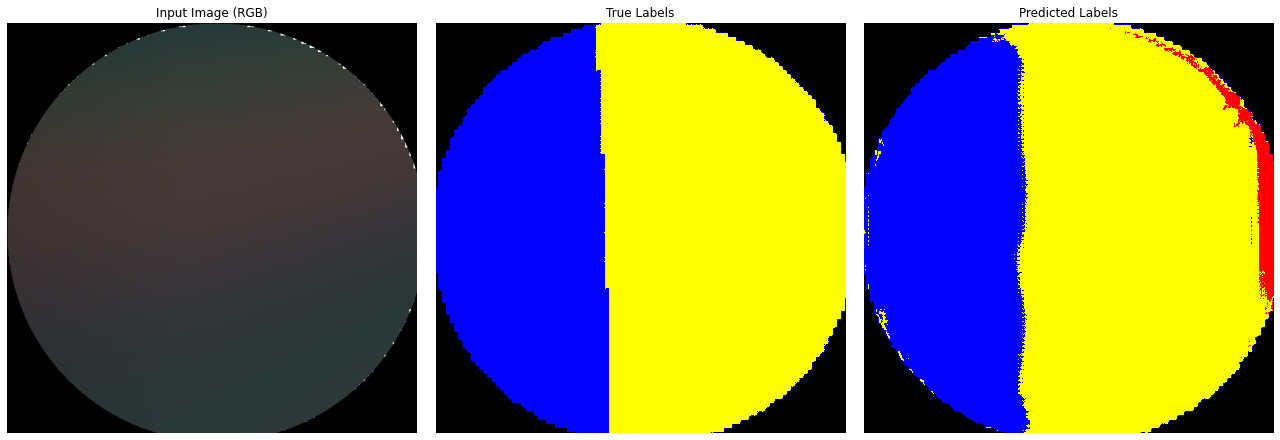

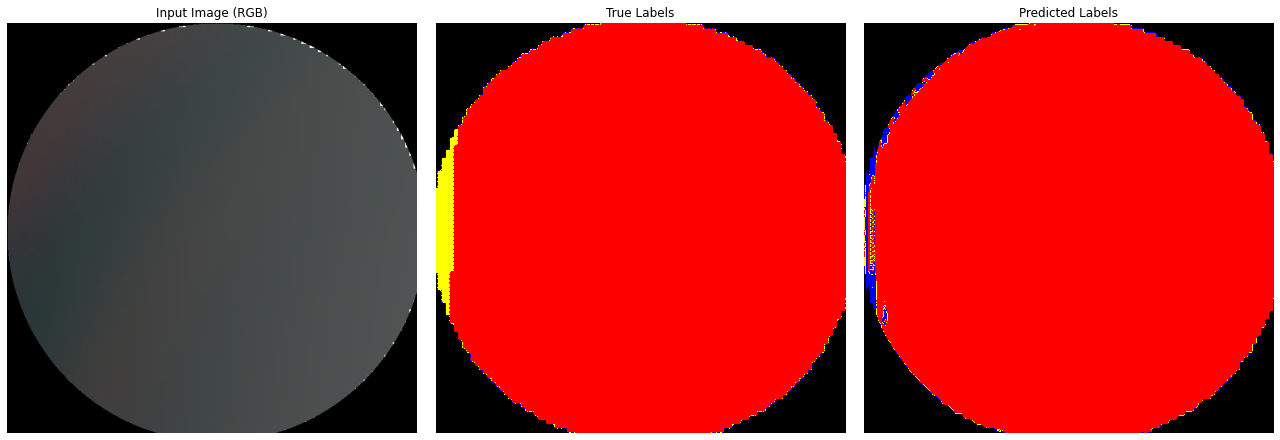

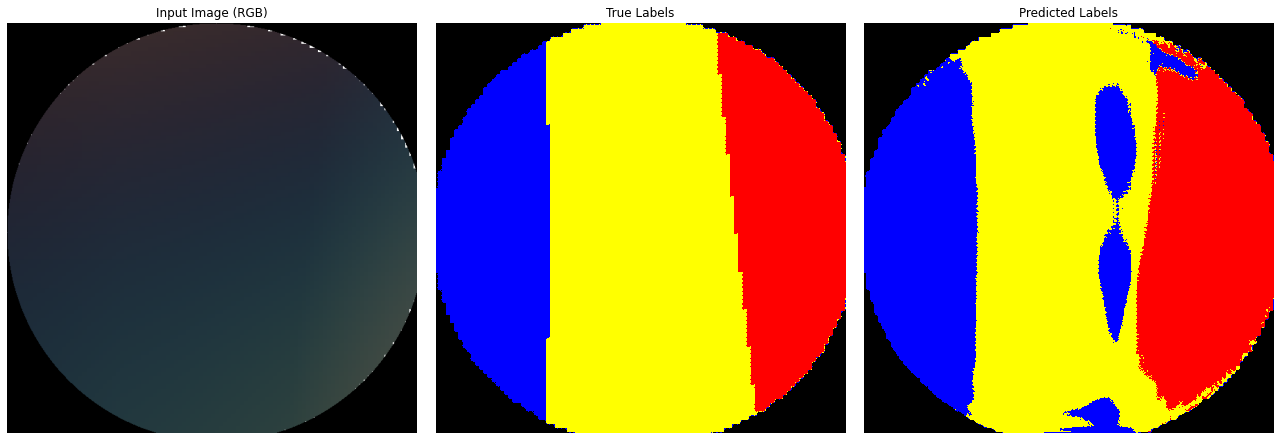

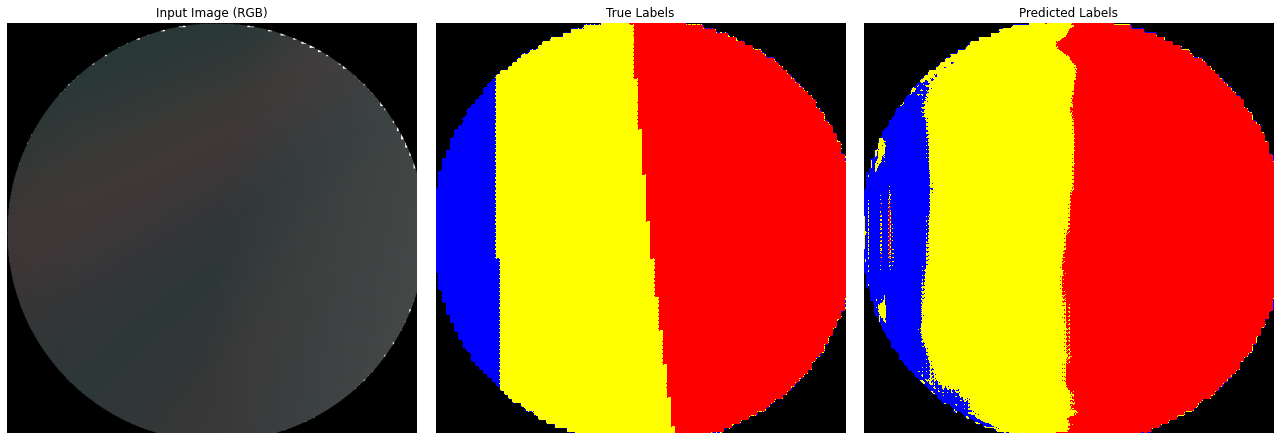

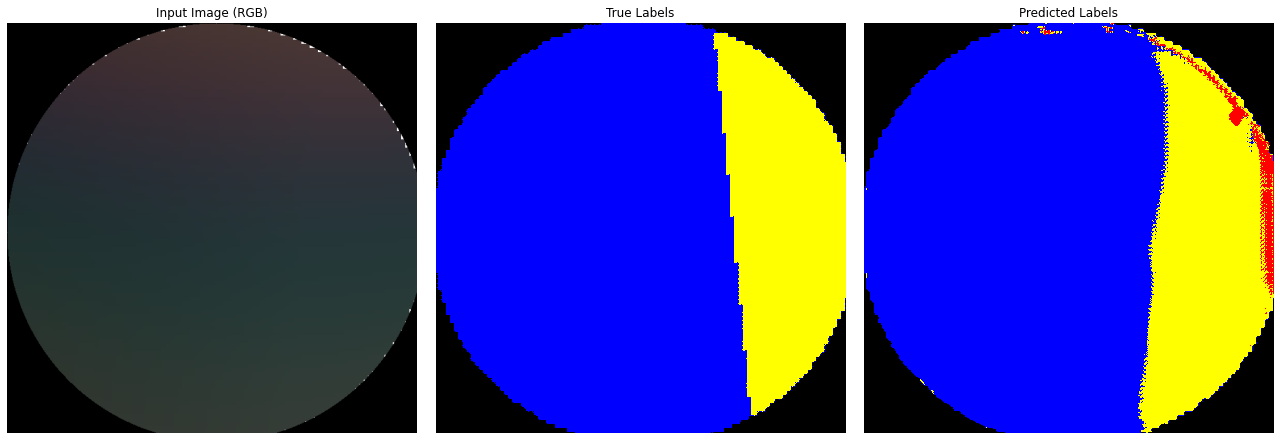

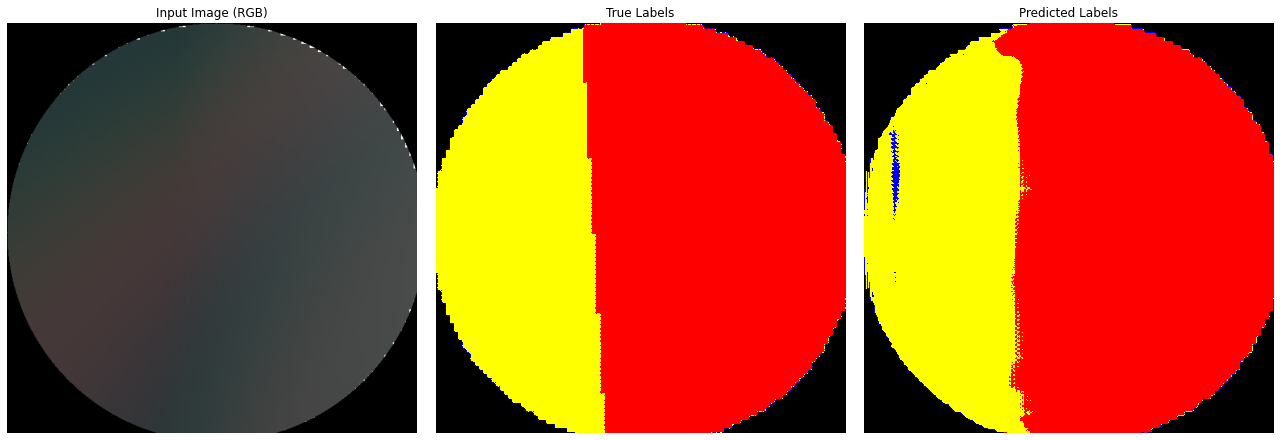

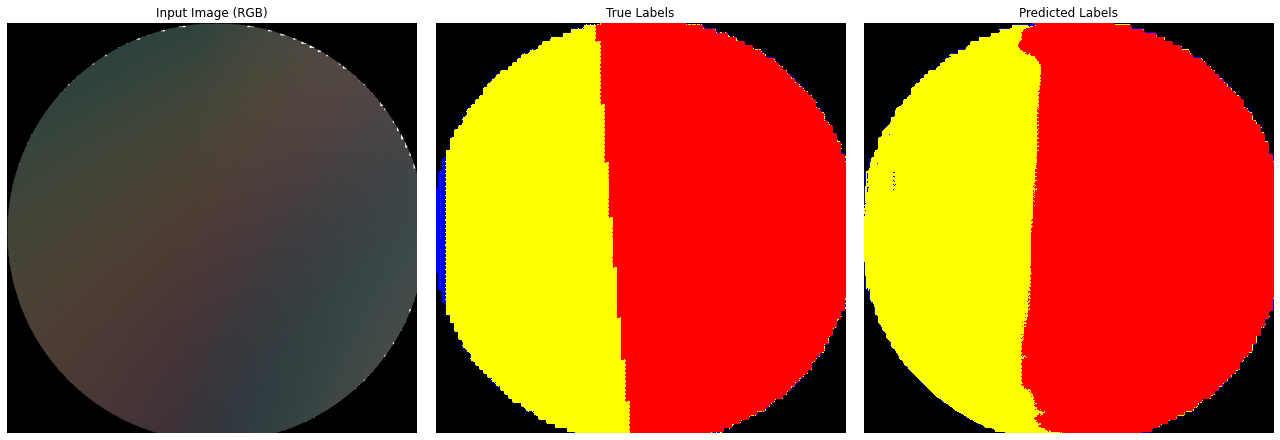

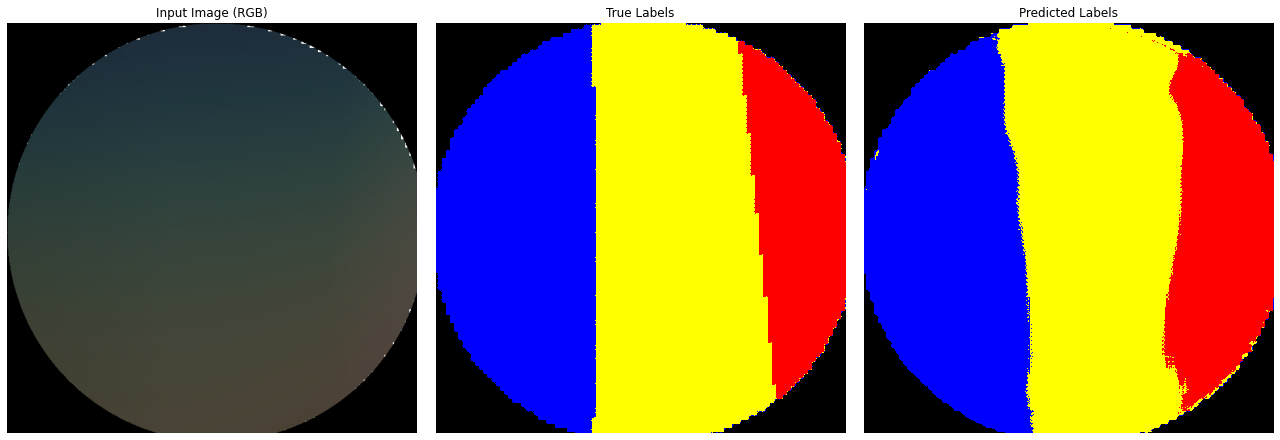

1/1 [==============================] - 0s 33ms/step


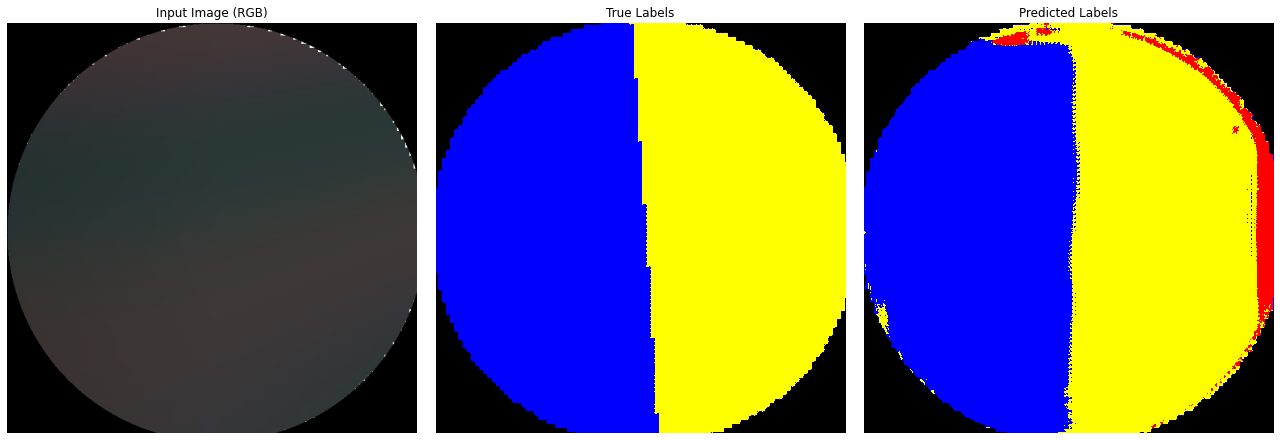

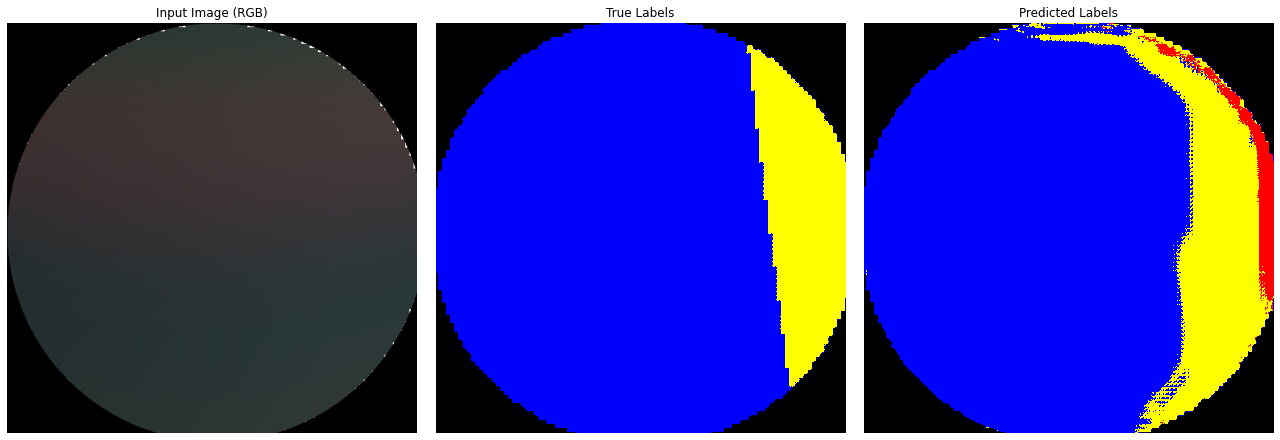

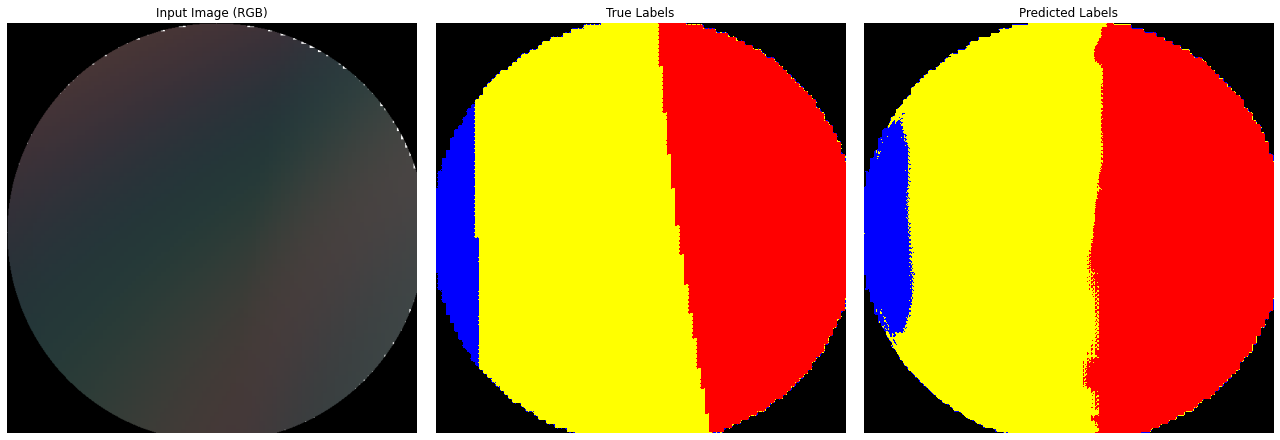

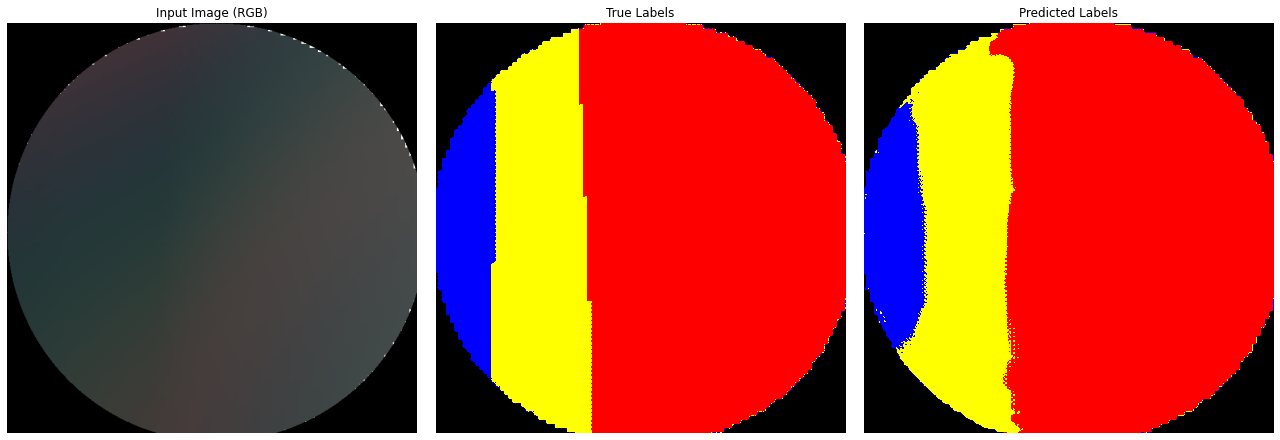

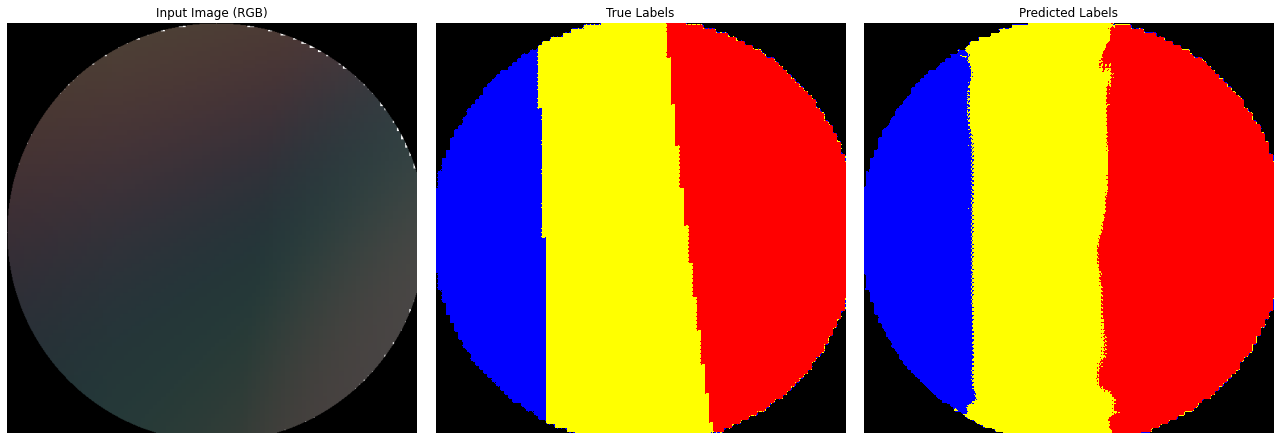

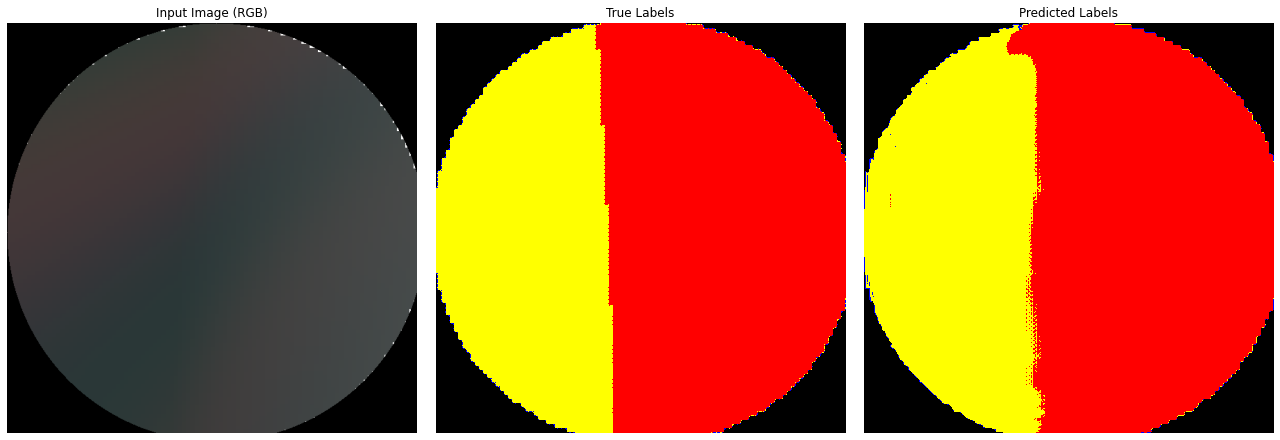

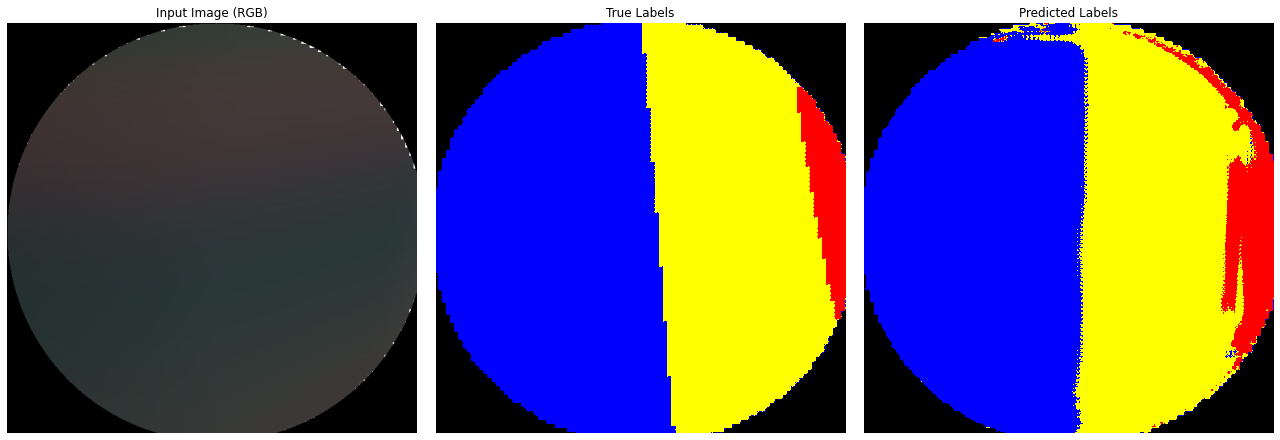

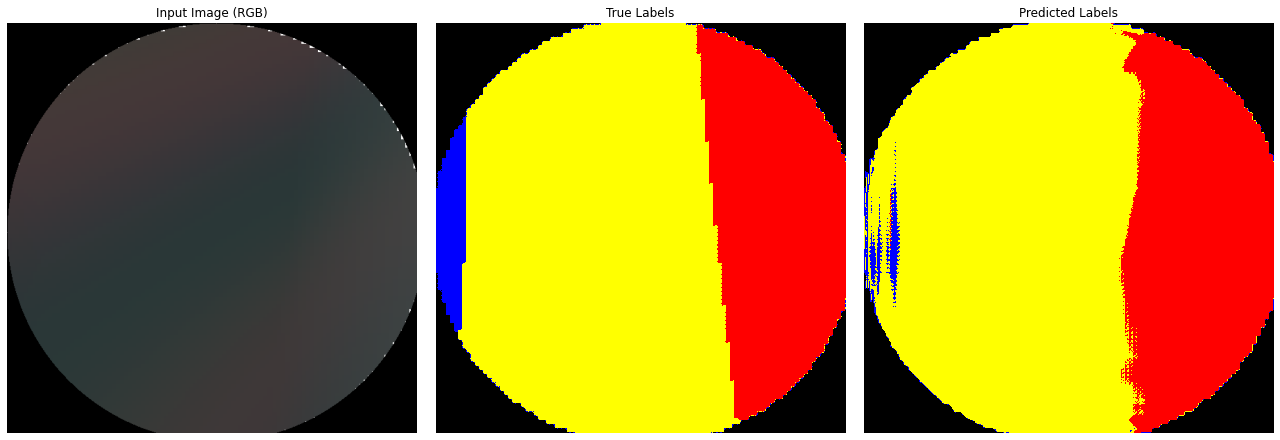

1/1 [==============================] - 0s 33ms/step


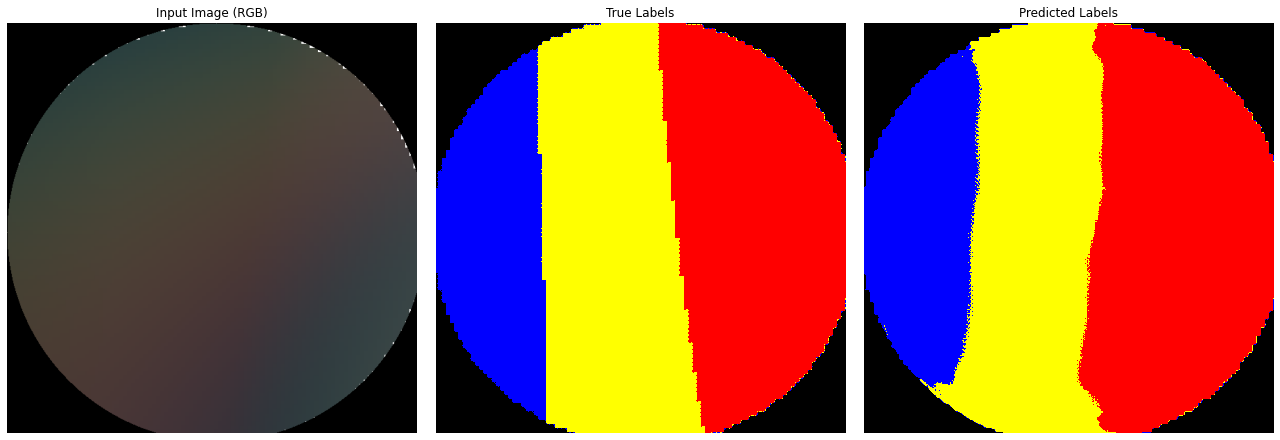

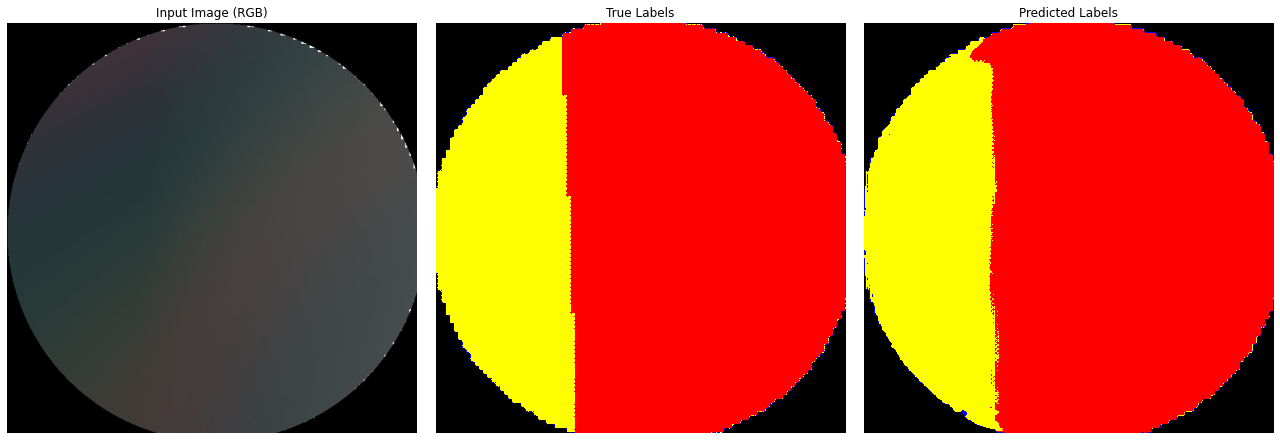

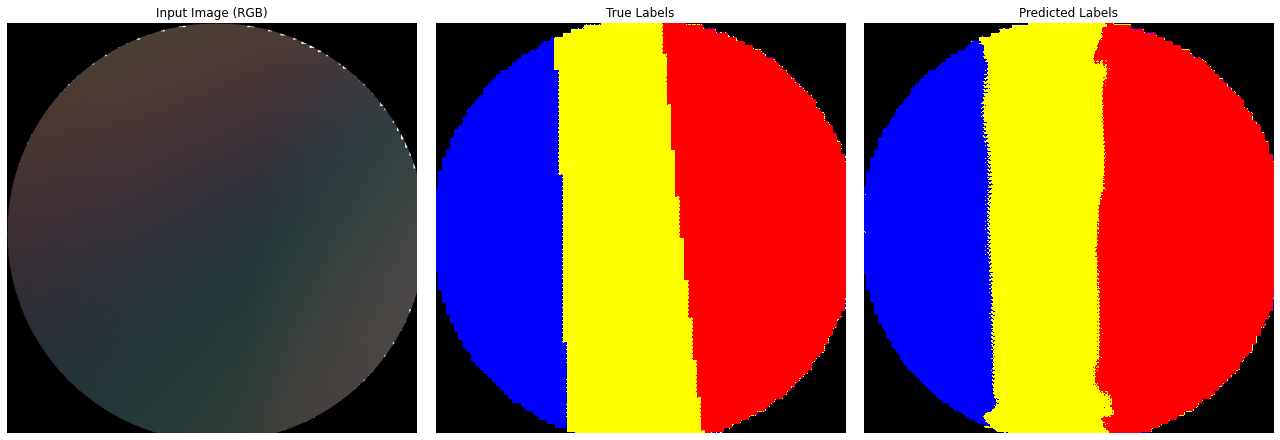

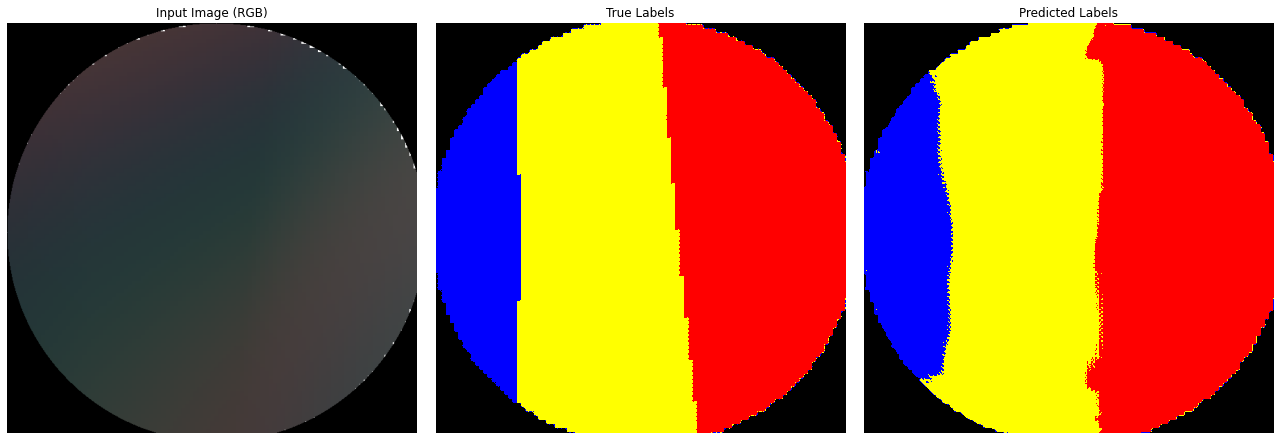

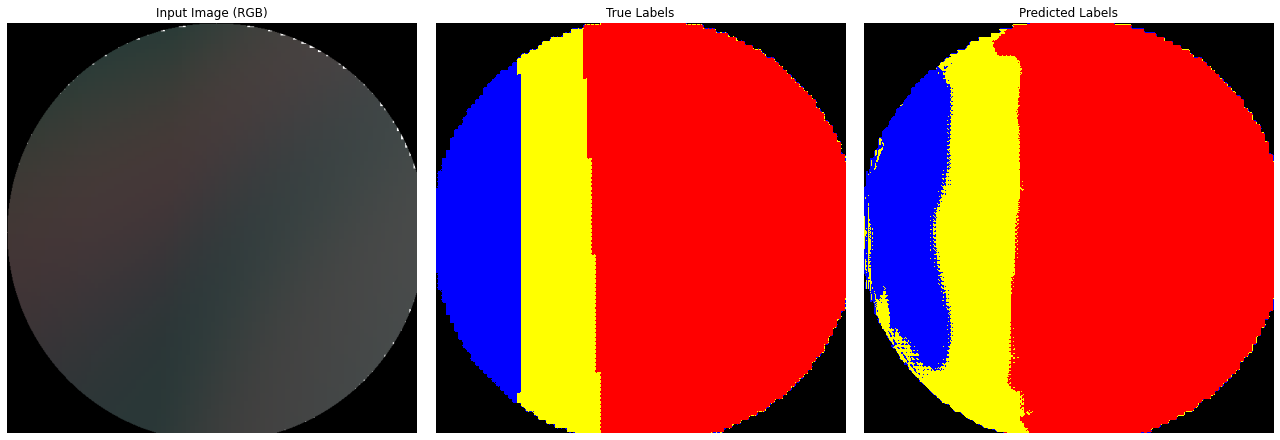

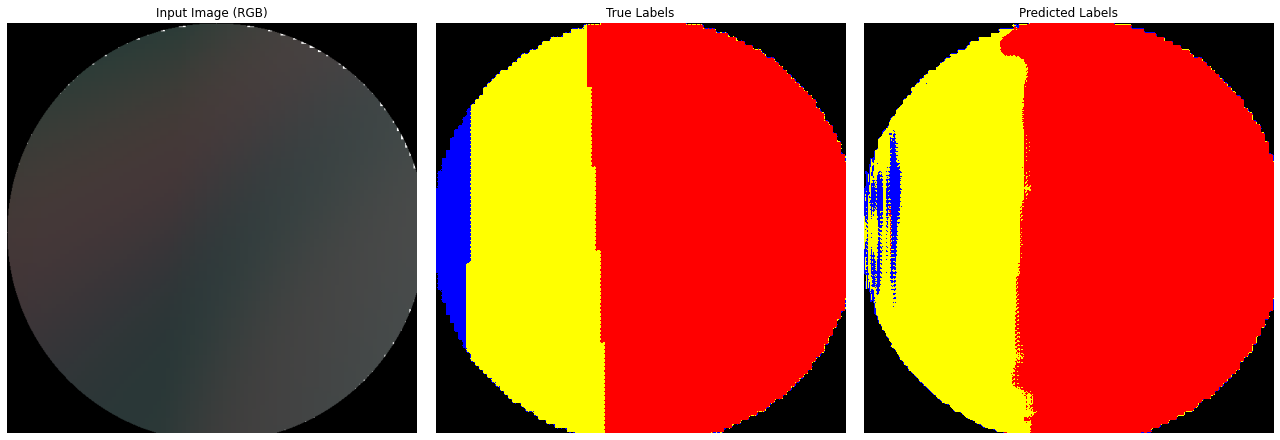

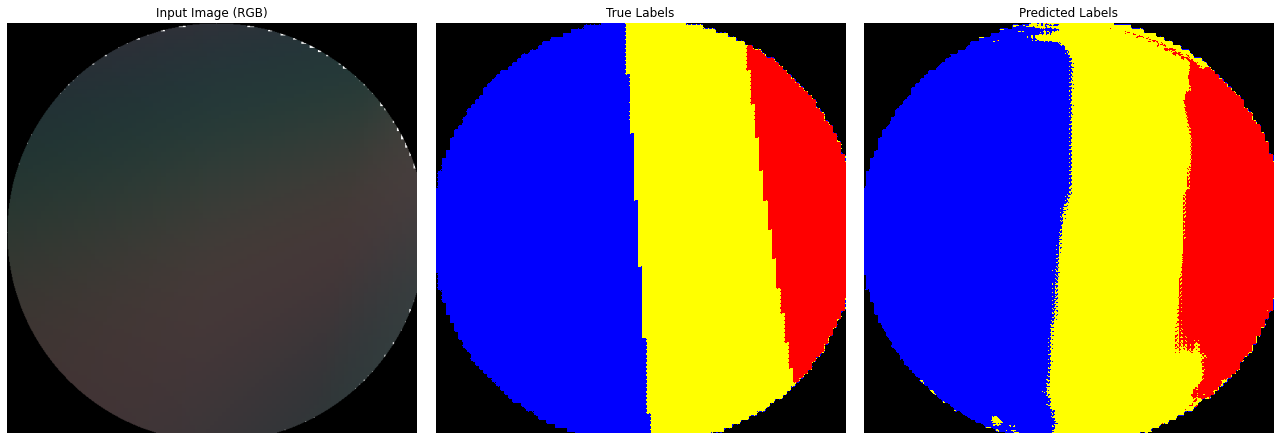

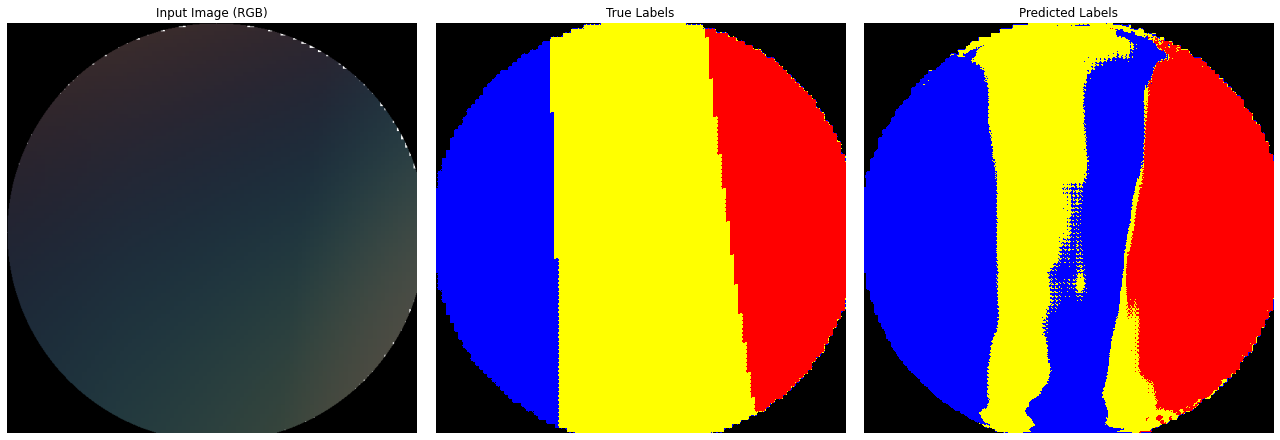

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Evaluate the model on the test set and calculate accuracy
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_acc}')

# Define a custom color map for labels
# Assuming:
# 0 - Background (Black)
# 1 - Blue---BaS
# 2 - Yellow---Sn2BaS3
# 3 - Red---SnS

custom_cmap = ListedColormap(['black', 'blue', 'yellow', 'red'])

# Function to visualize predictions with custom colors
def visualize_predictions(generator, model, num_samples=5):
    """
    Visualize model predictions on the test set with custom colors.

    Parameters:
        generator (DataGenerator): Test set data generator.
        model (tf.keras.Model): Trained model.
        num_samples (int): Number of samples to visualize.
    """
    # Ensure num_samples does not exceed the number of available batches
    total_batches = len(generator)
    samples_per_batch = generator.batch_size
    max_samples = total_batches * samples_per_batch

    if num_samples > max_samples:
        print(f"Requested {num_samples} samples, but only {max_samples} are available.")
        num_samples = max_samples

    samples_visualized = 0

    for batch_idx in range(total_batches):
        X_batch, y_true_batch = generator[batch_idx]
        y_pred_batch = model.predict(X_batch)

        for i in range(X_batch.shape[0]):
            if samples_visualized >= num_samples:
                return

            input_image = X_batch[i]  # Input image
            y_true = np.argmax(y_true_batch[i], axis=-1)  # True labels
            y_pred = np.argmax(y_pred_batch[i], axis=-1)  # Predicted labels

            # Create a figure with three subplots
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))

            # Display the first RGB image (assuming the first 3 channels are RGB)
            axes[0].imshow(input_image[..., :3].astype(np.uint8))
            axes[0].set_title("Input Image (RGB)")
            axes[0].axis('off')

            # Display the true labels with custom color map
            axes[1].imshow(y_true, cmap=custom_cmap, vmin=0, vmax=num_classes-1)
            axes[1].set_title("True Labels")
            axes[1].axis('off')

            # Display the predicted labels with custom color map
            axes[2].imshow(y_pred, cmap=custom_cmap, vmin=0, vmax=num_classes-1)
            axes[2].set_title("Predicted Labels")
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

            samples_visualized += 1

# Visualize some predictions on the test set with custom colors
visualize_predictions(test_generator, model, num_samples=40)


5/5 [==============================] - 30s 6s/step - loss: 0.1448 - accuracy: 0.9443
Test Loss: 0.14484967291355133, Test Accuracy: 0.9442773461341858
1/1 [==============================] - 0s 34ms/step


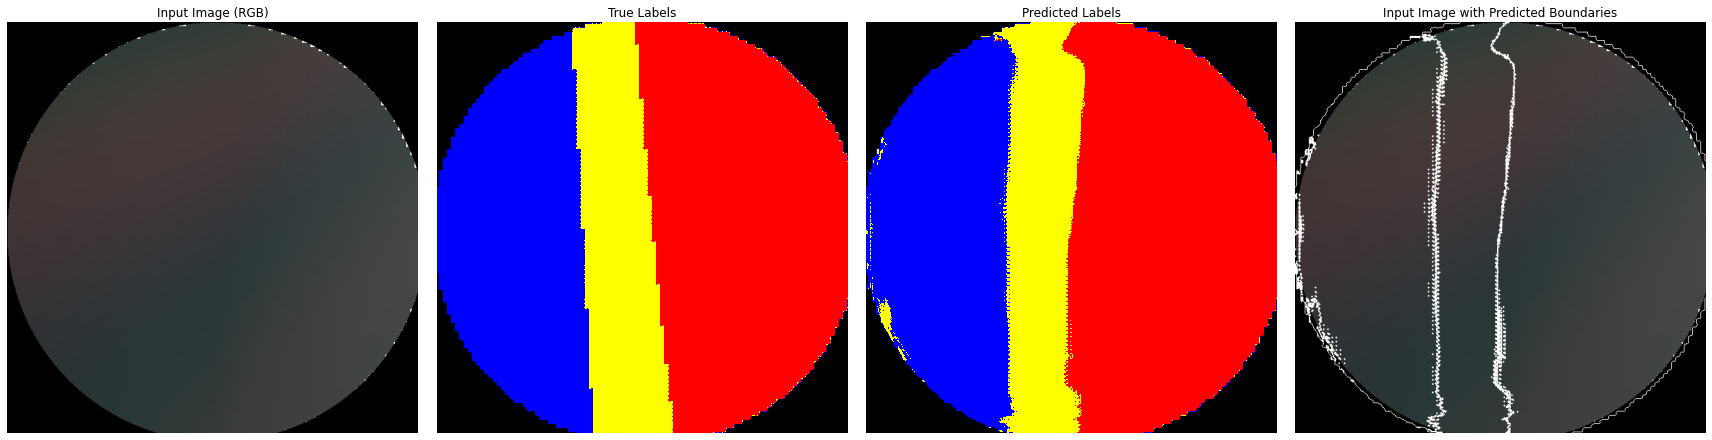

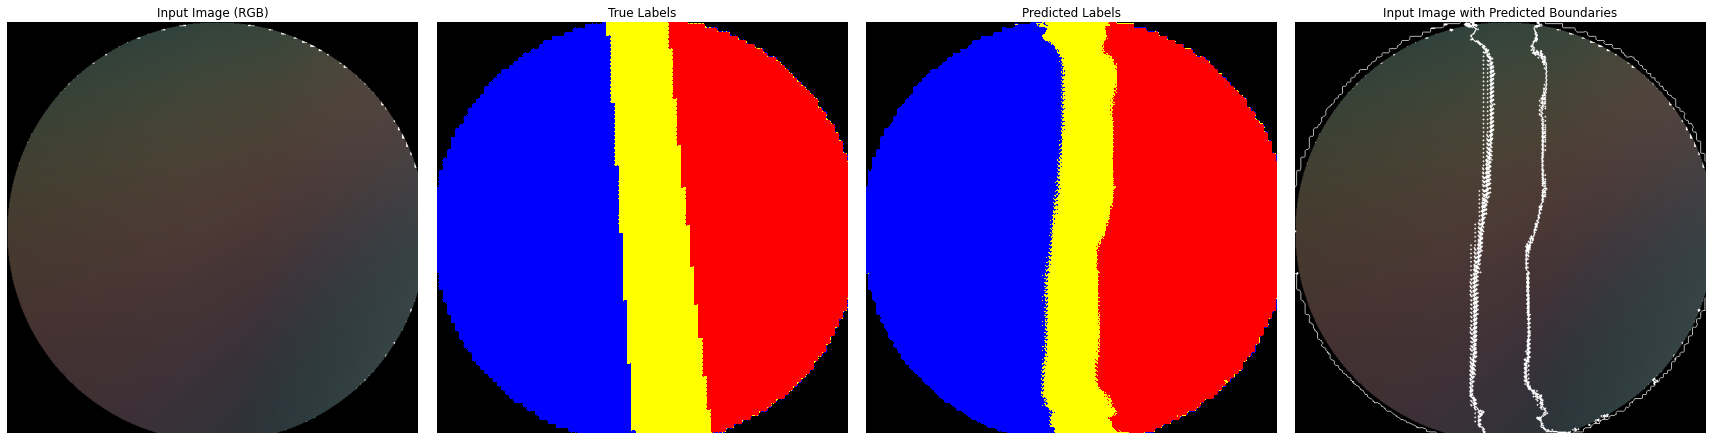

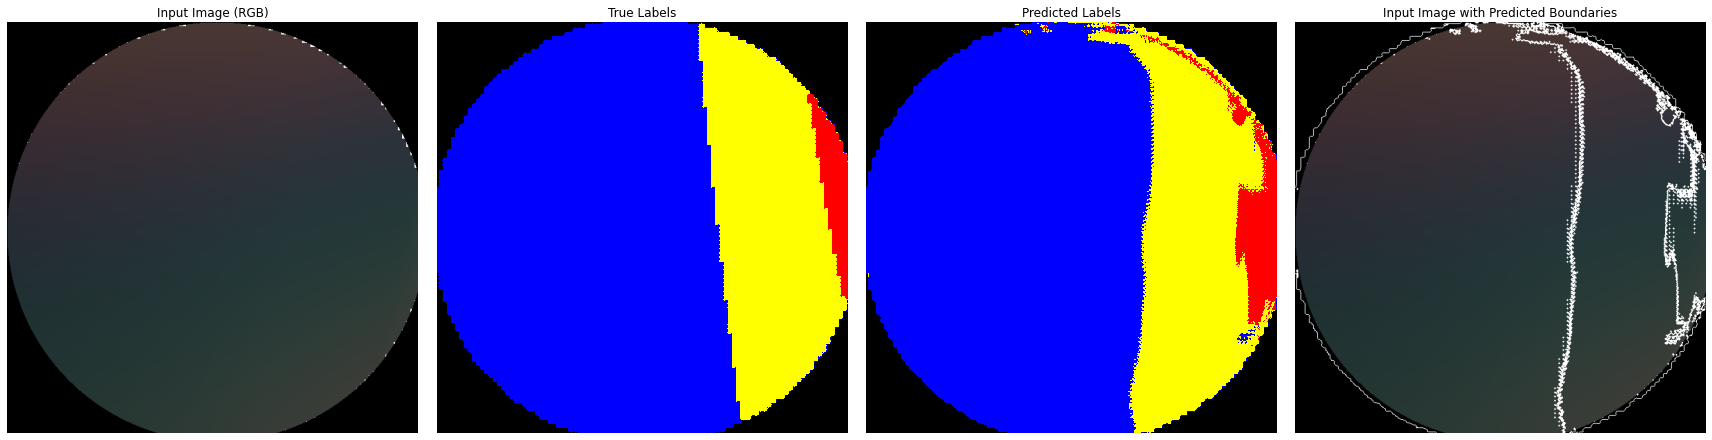

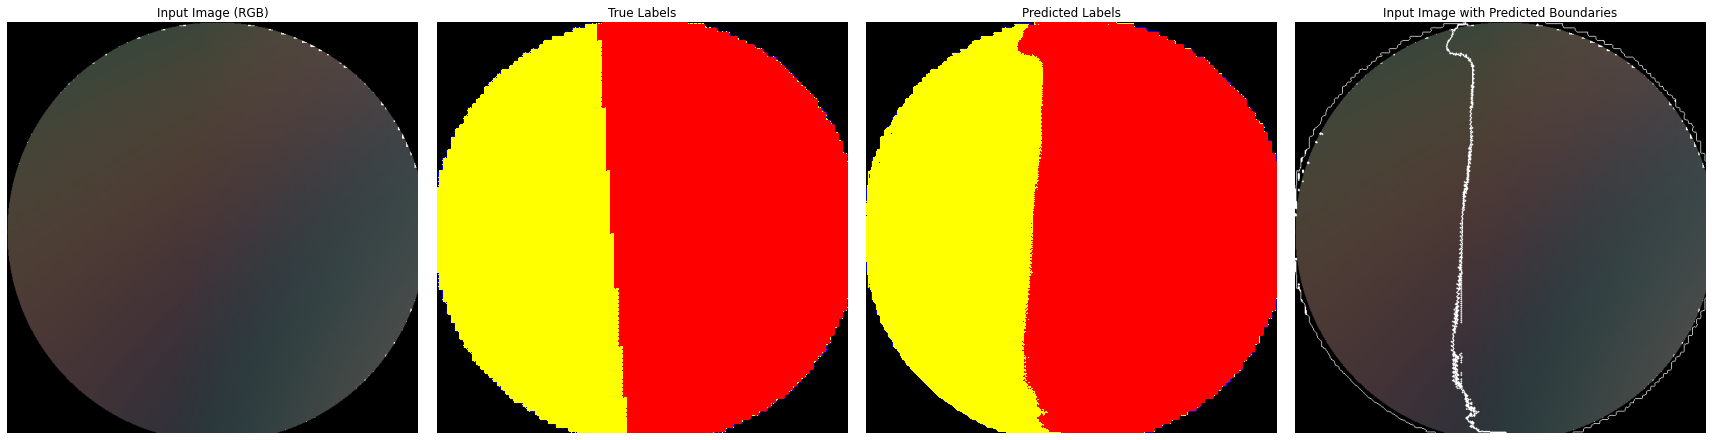

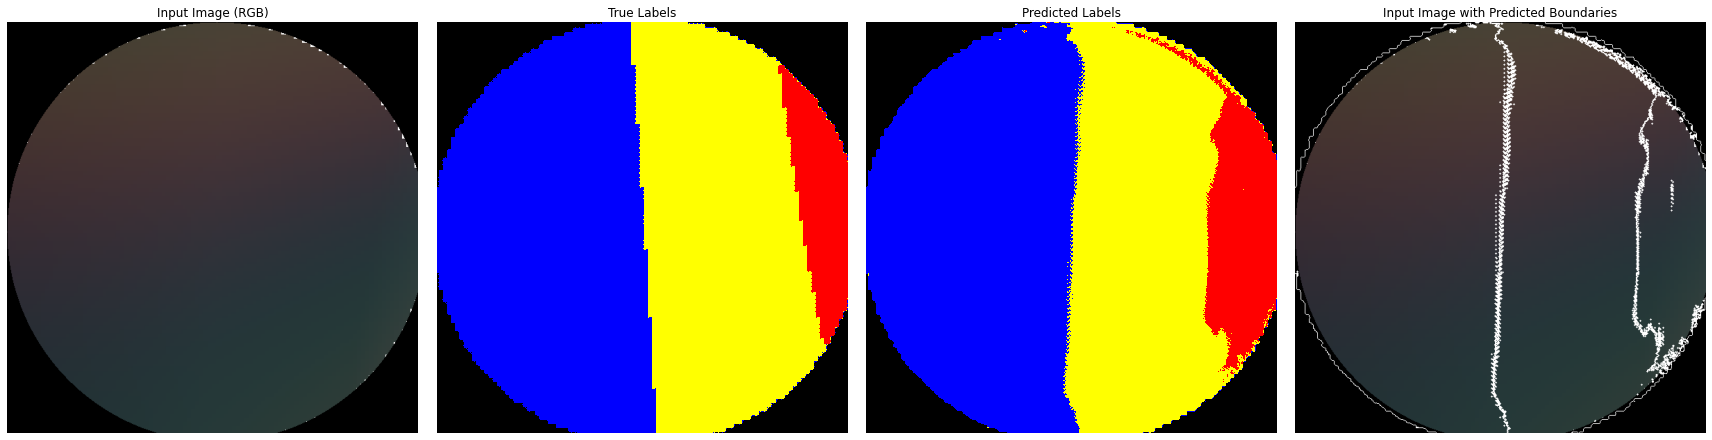

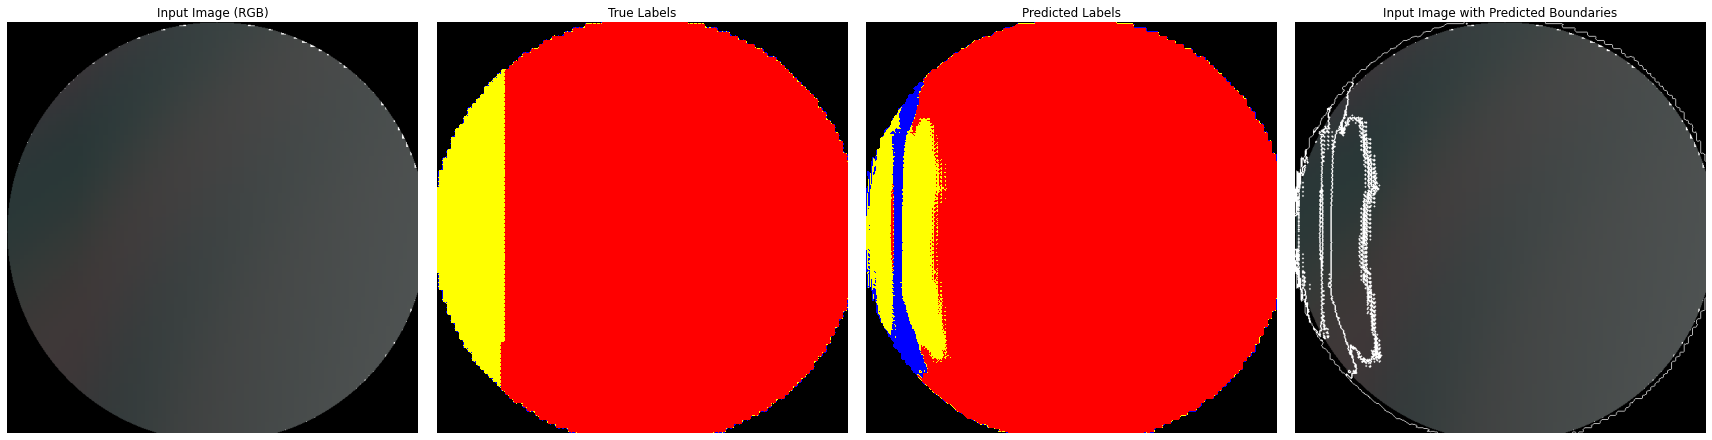

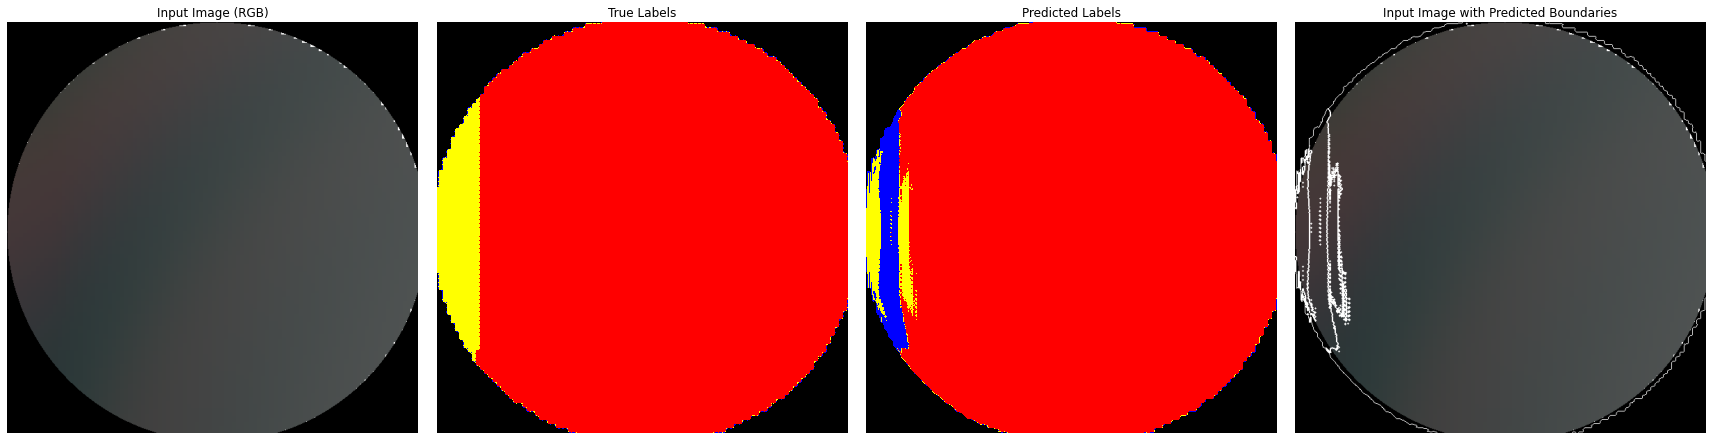

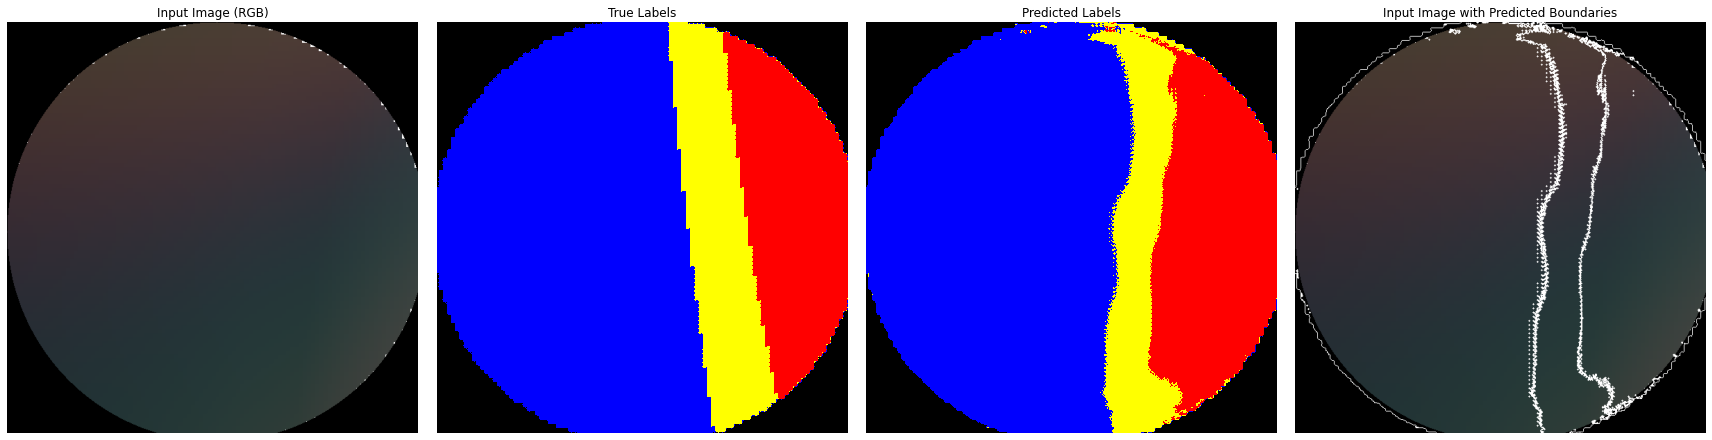

1/1 [==============================] - 0s 40ms/step


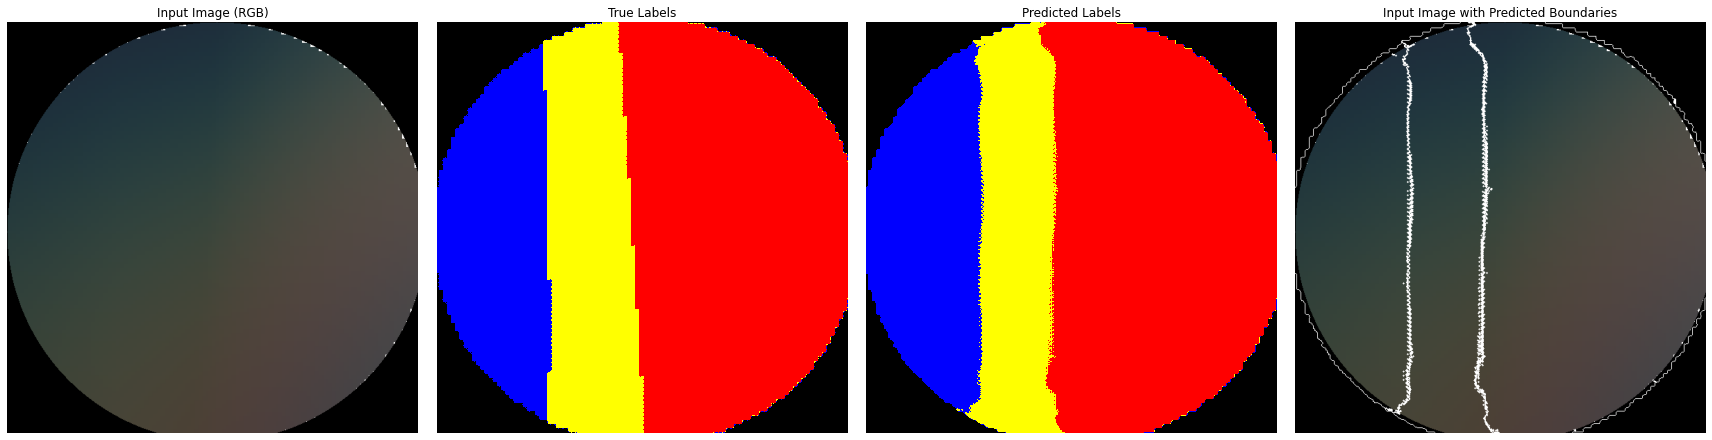

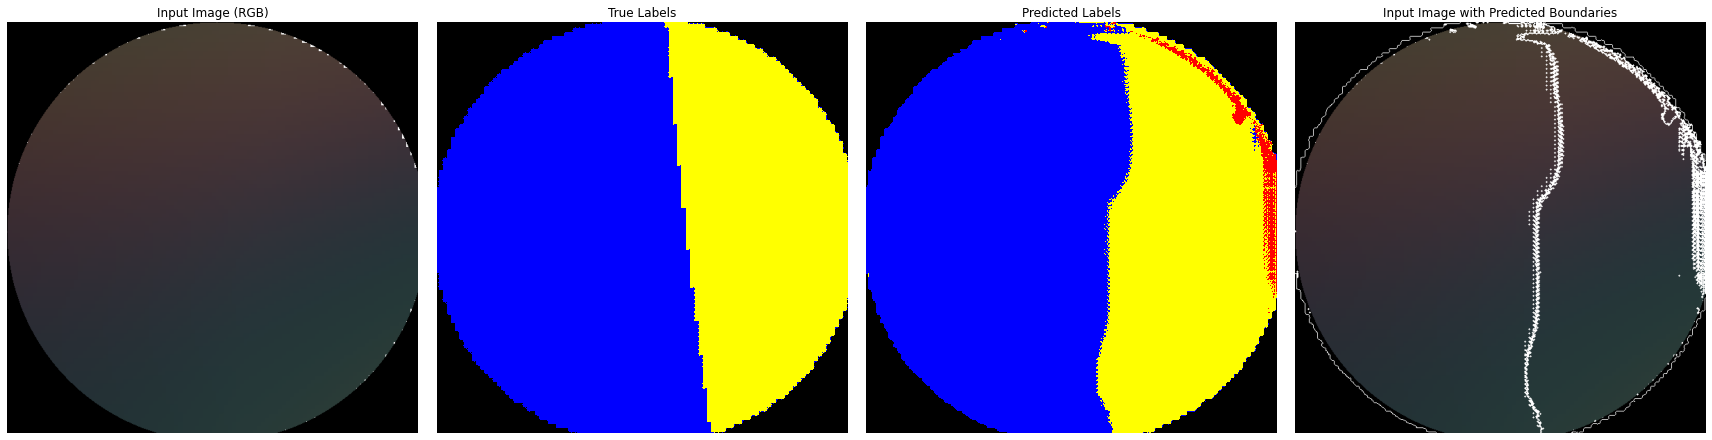

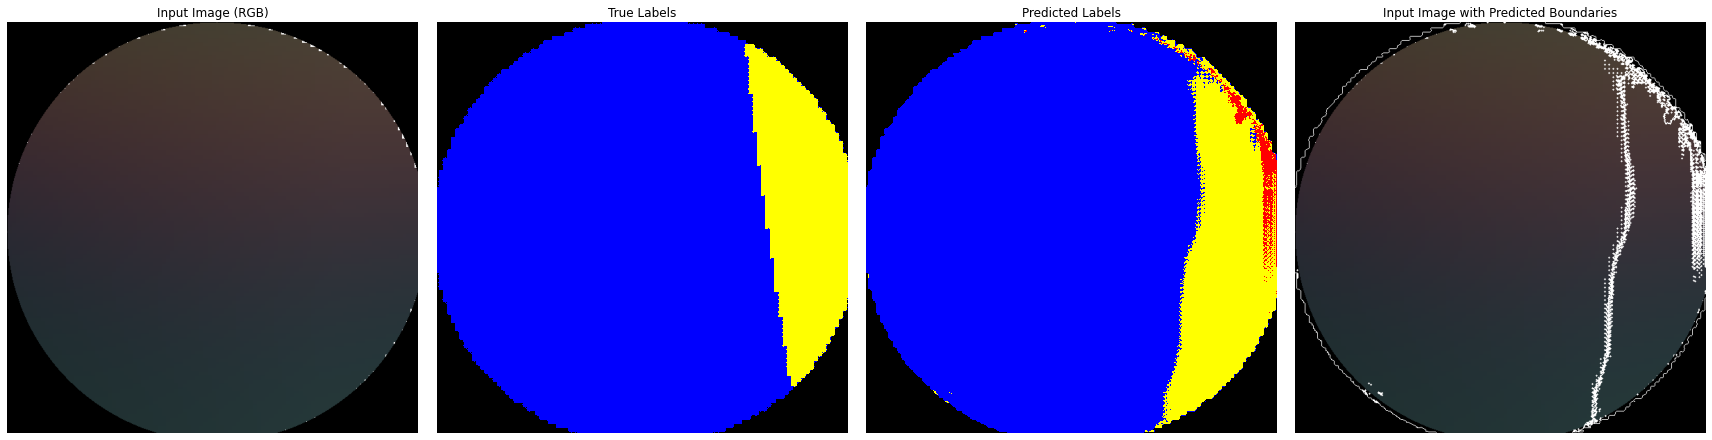

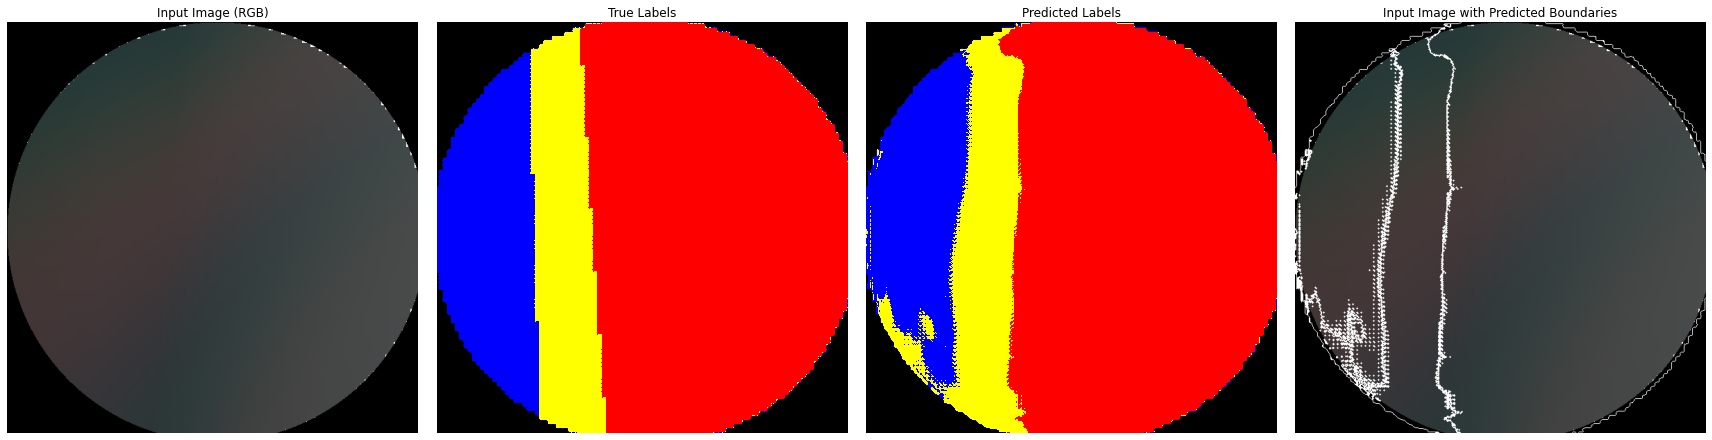

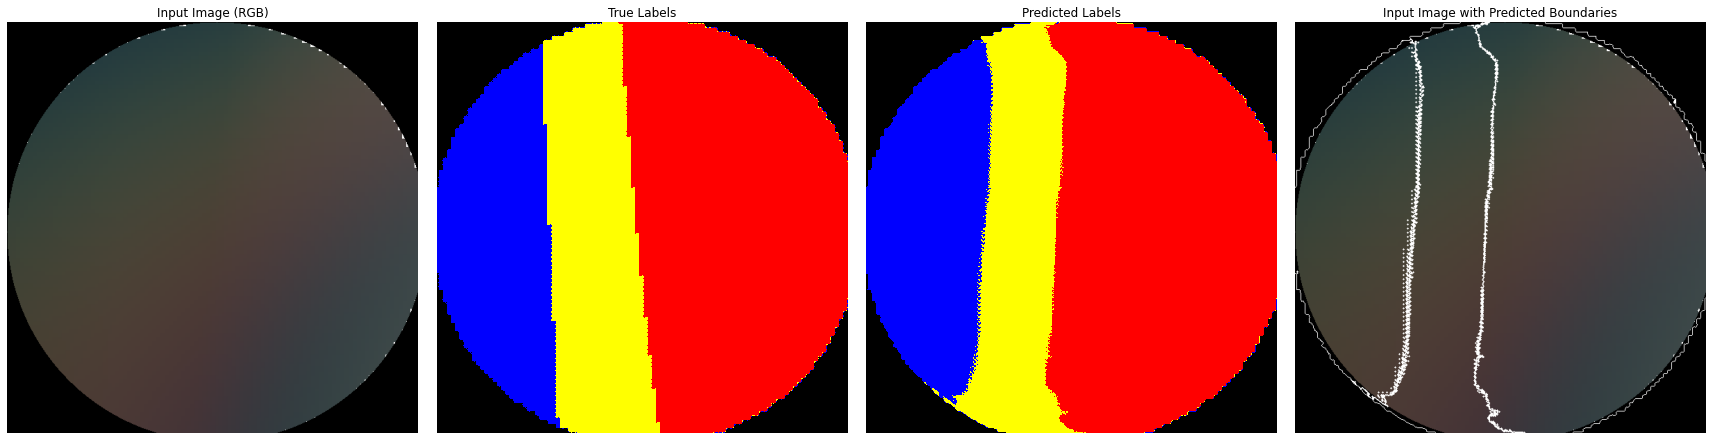

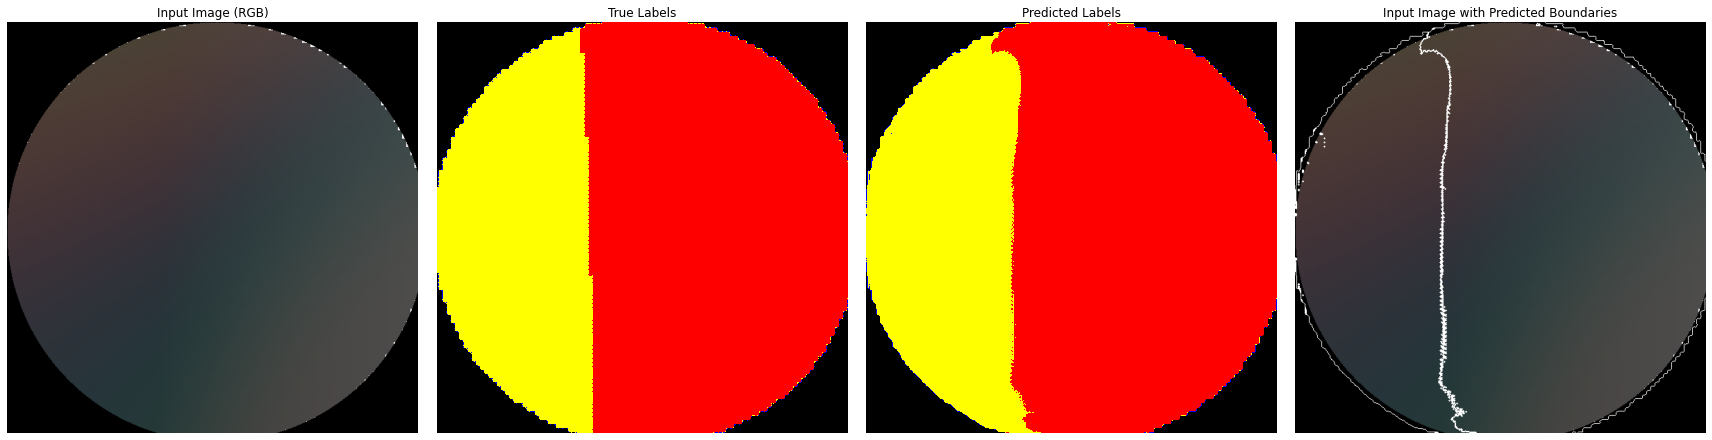

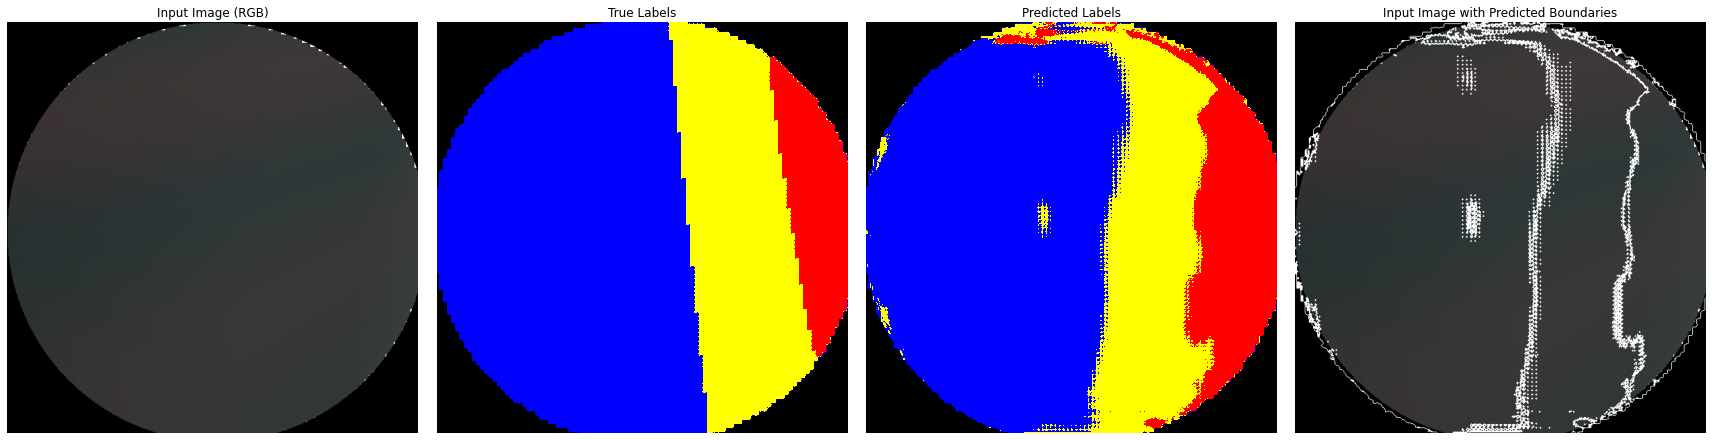

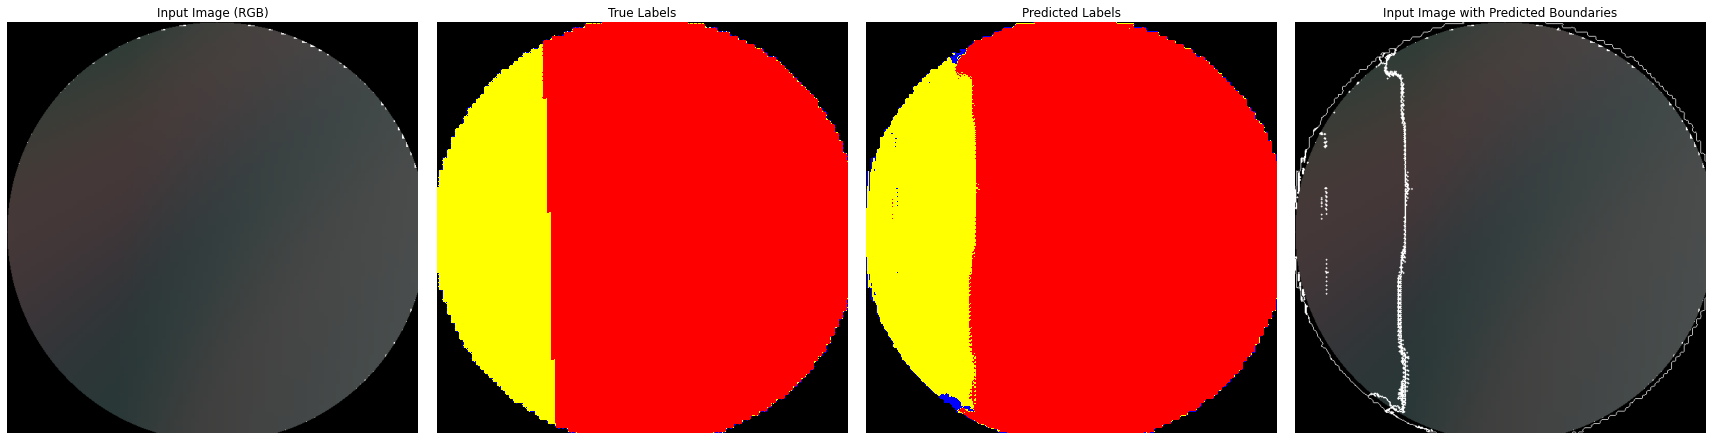

1/1 [==============================] - 0s 34ms/step


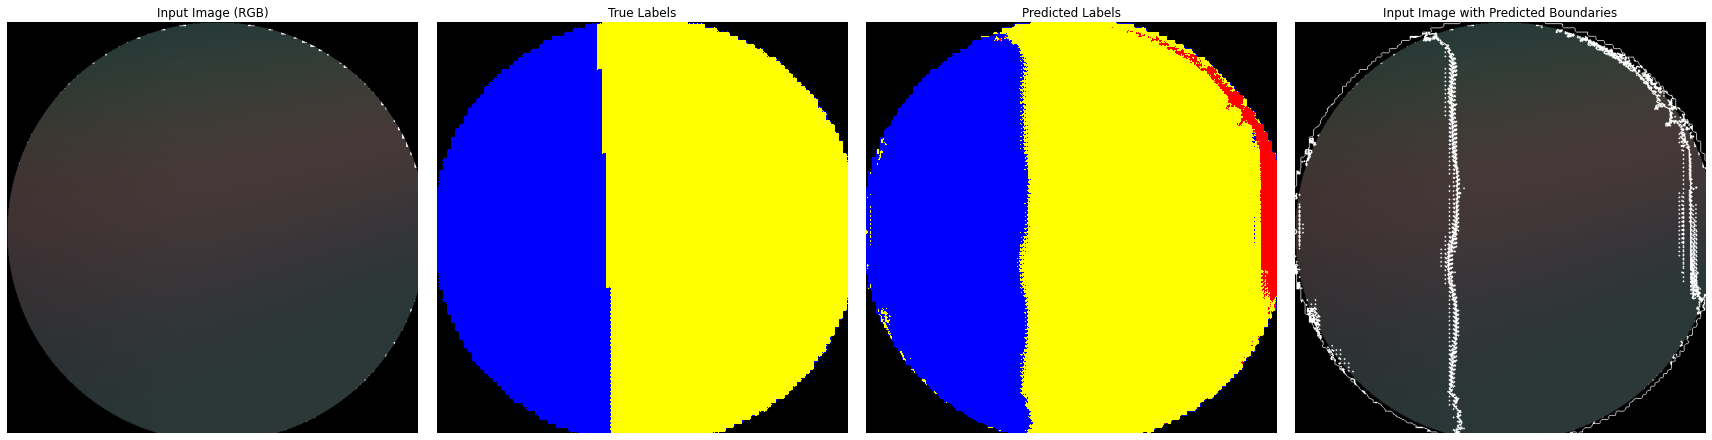

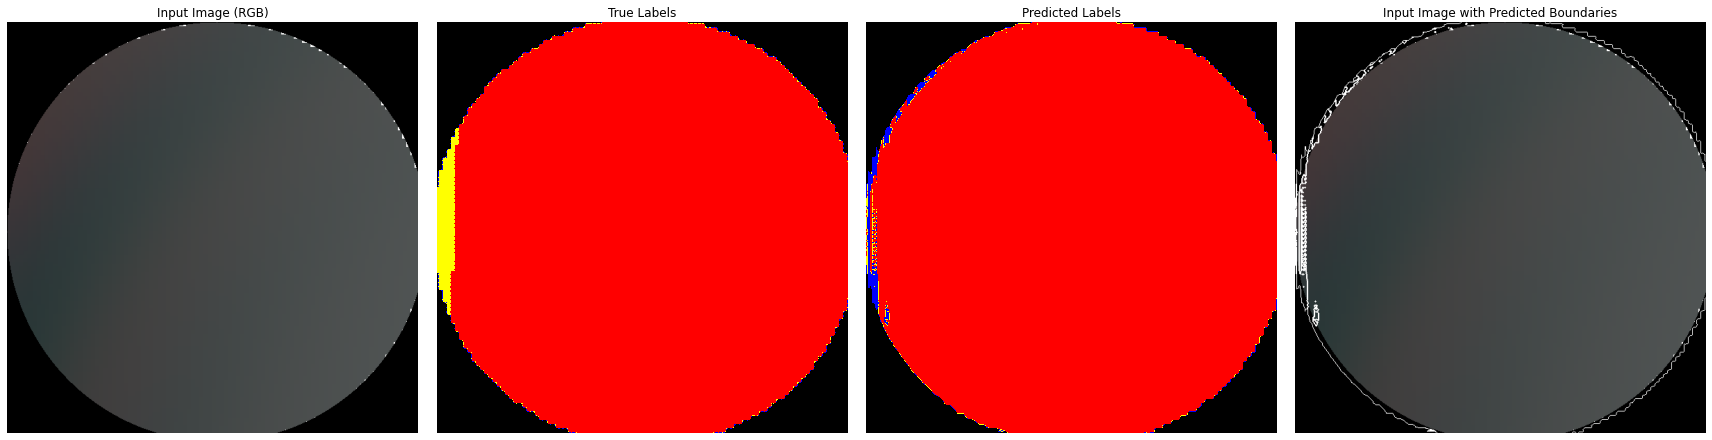

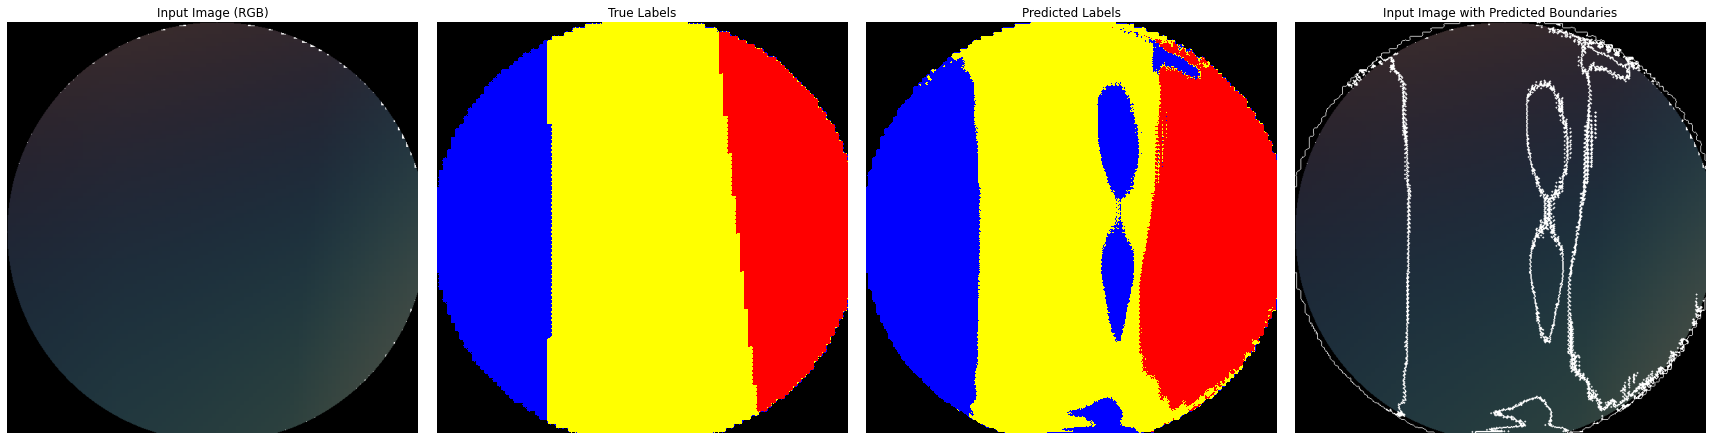

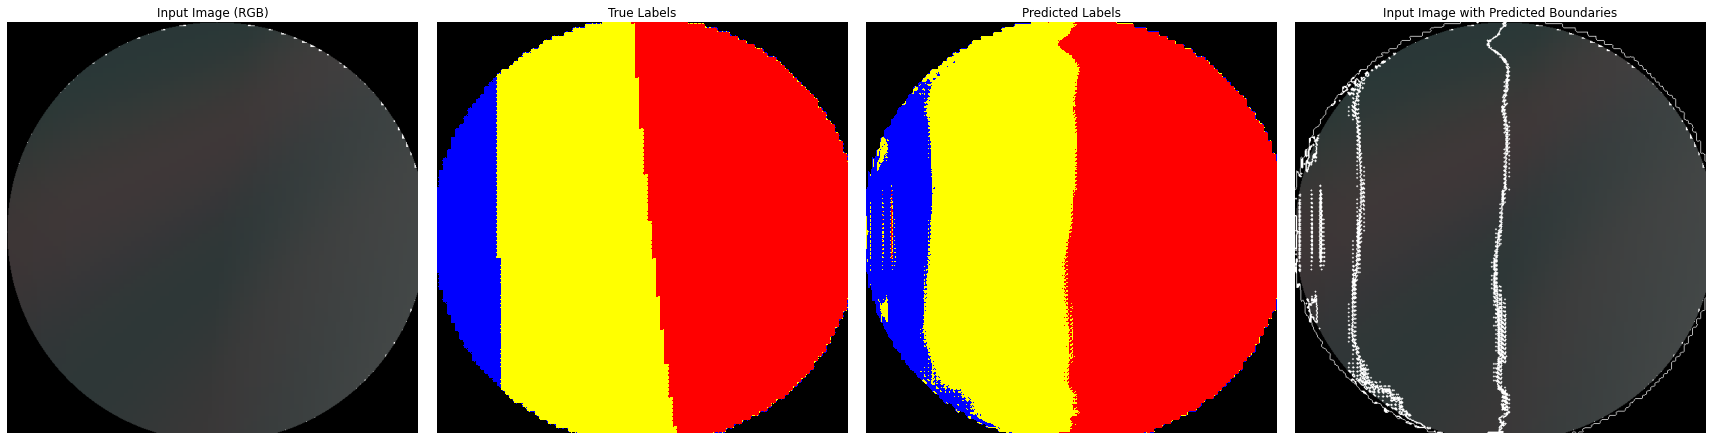

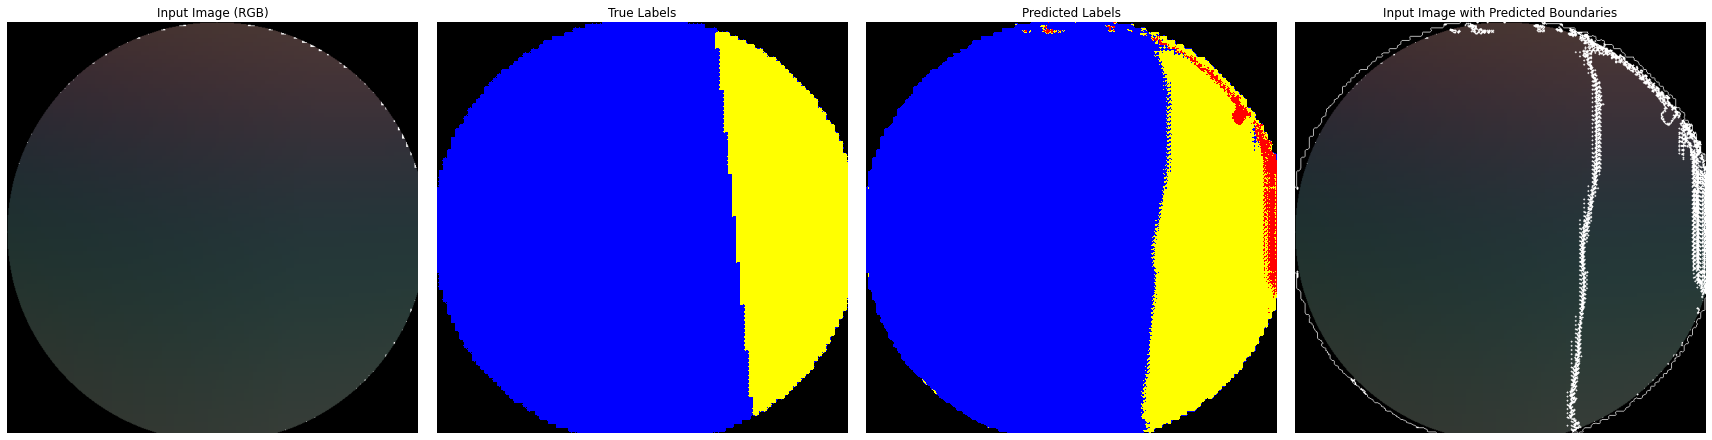

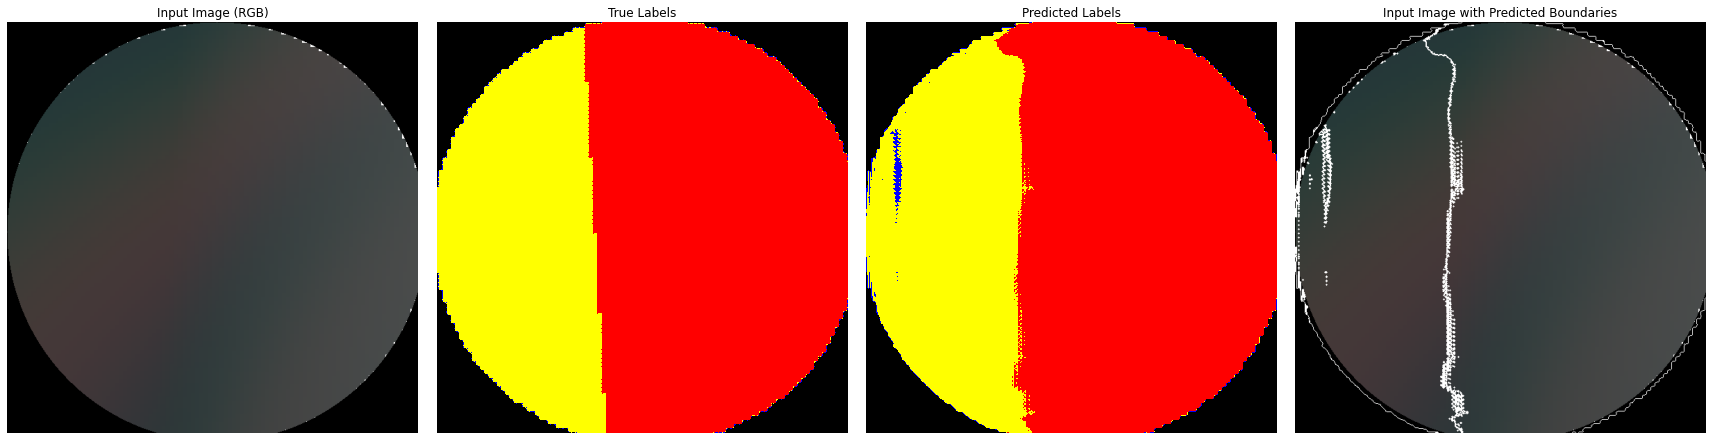

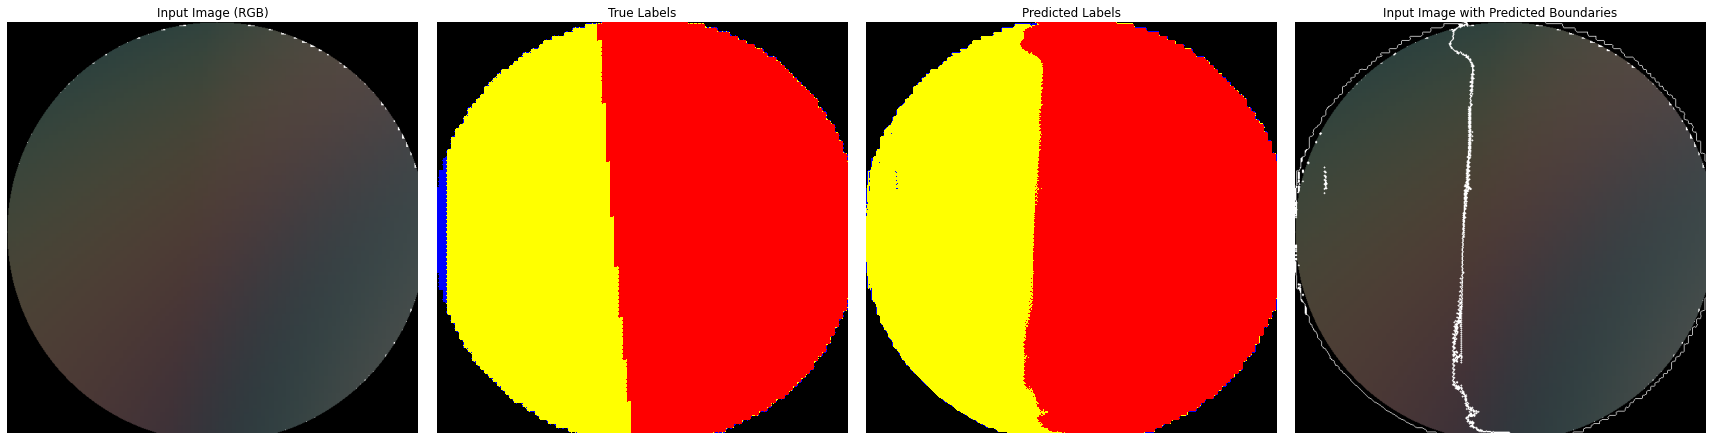

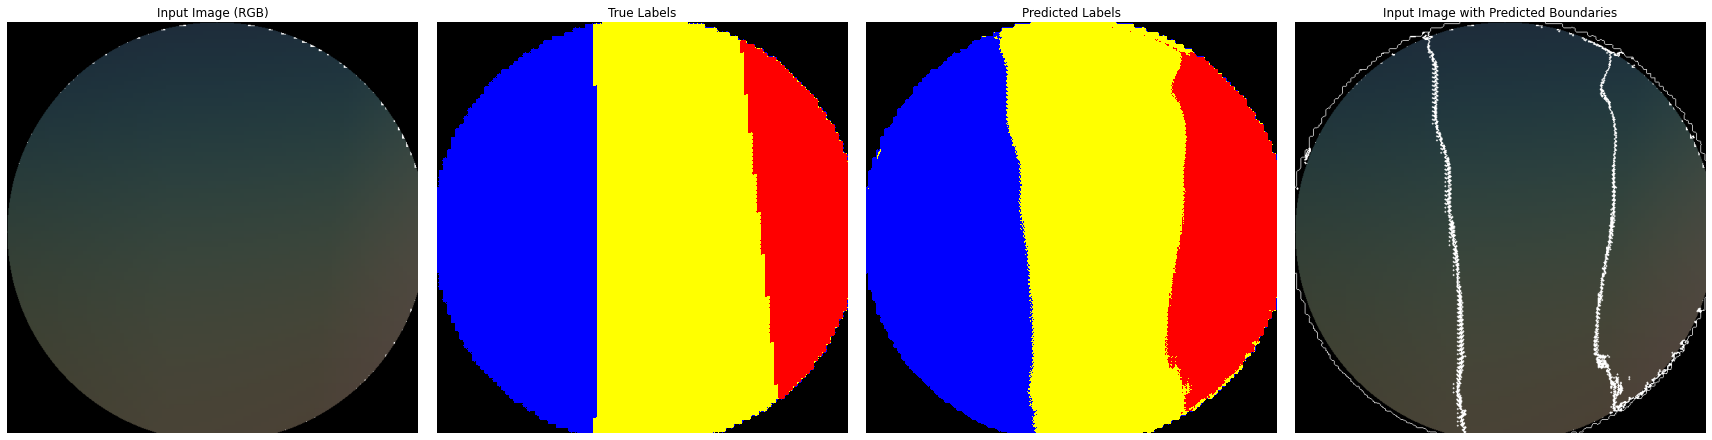

1/1 [==============================] - 0s 50ms/step


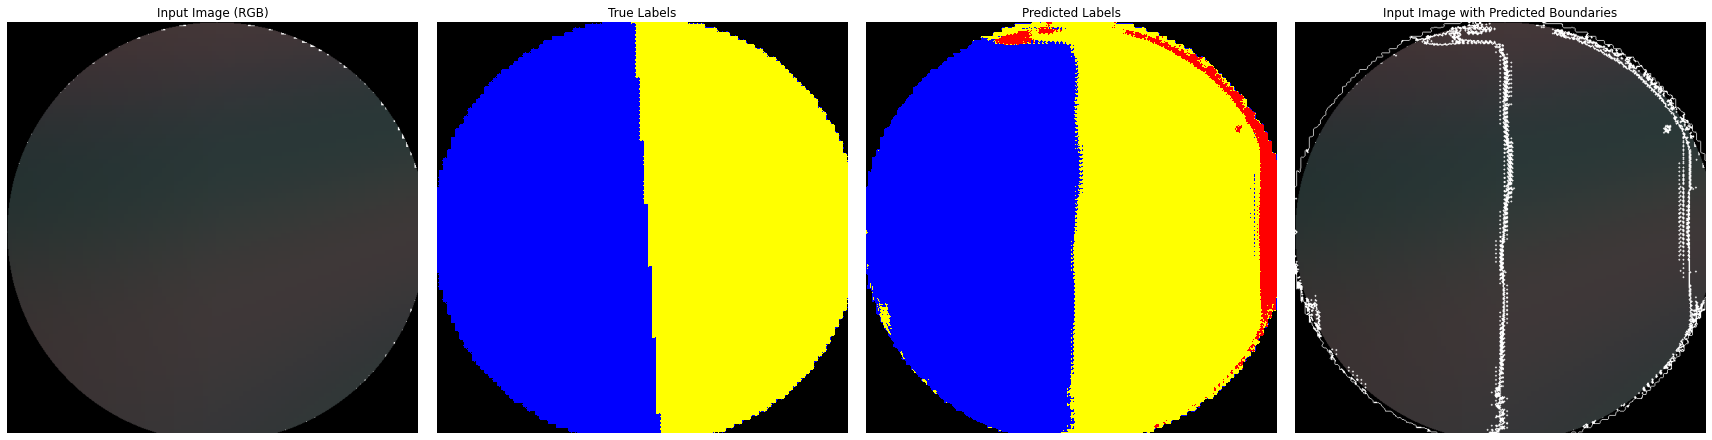

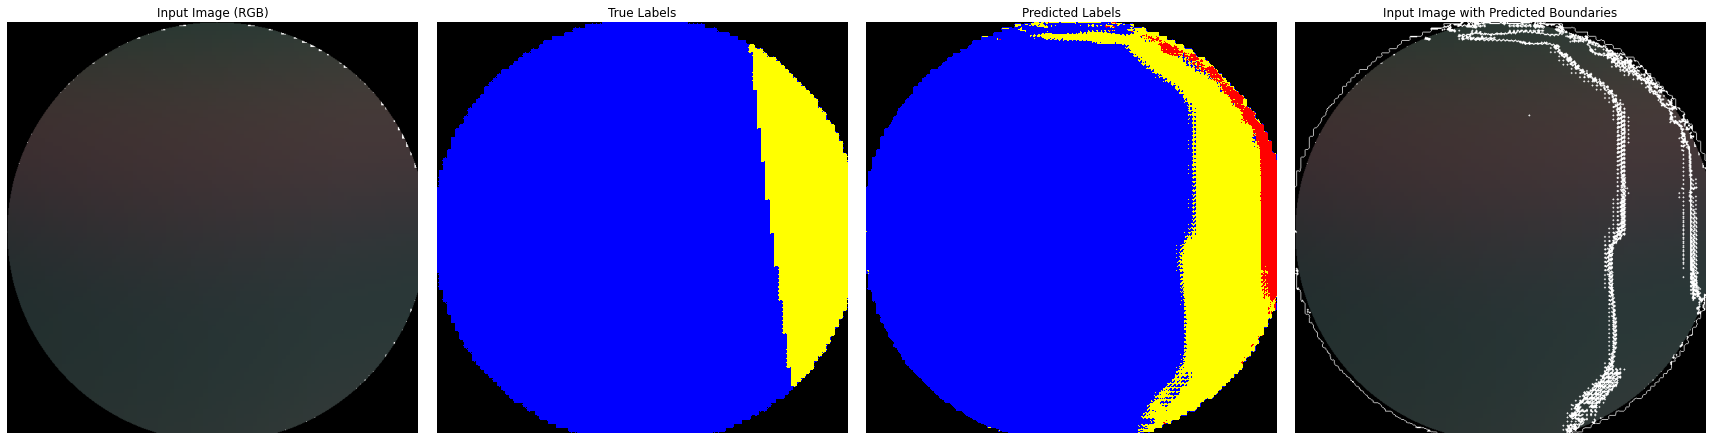

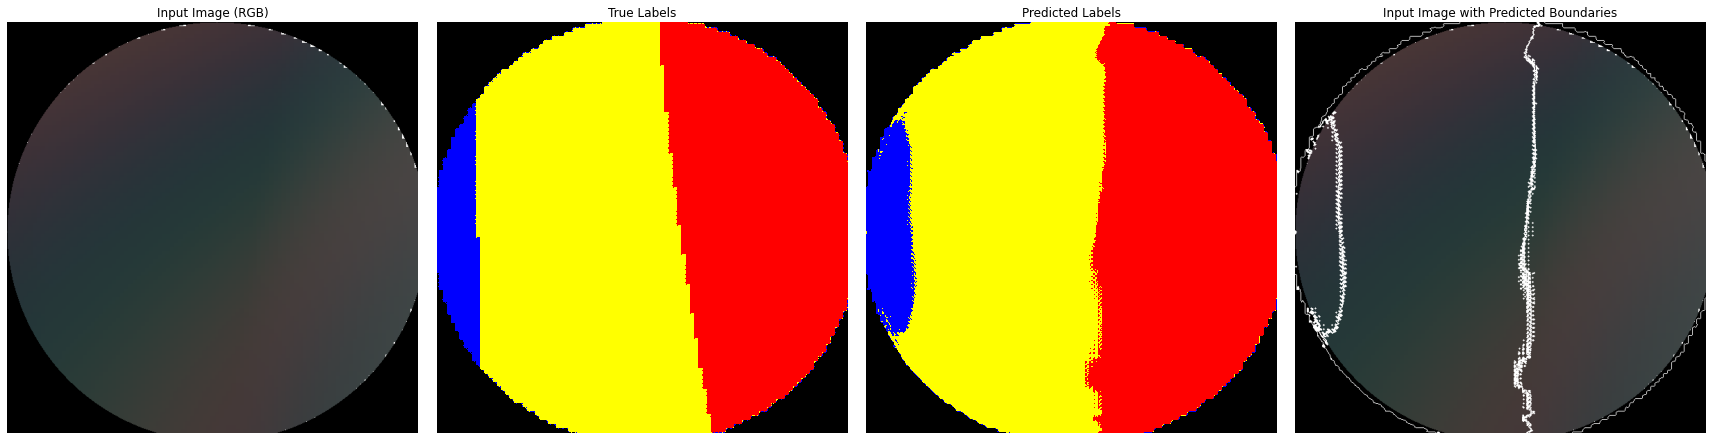

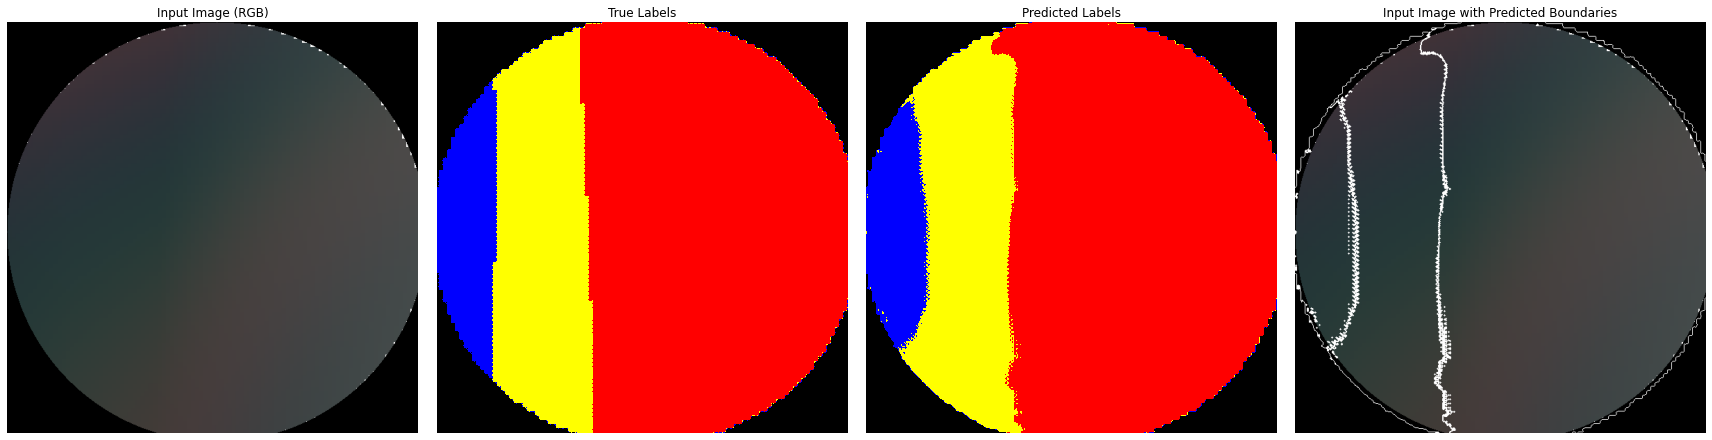

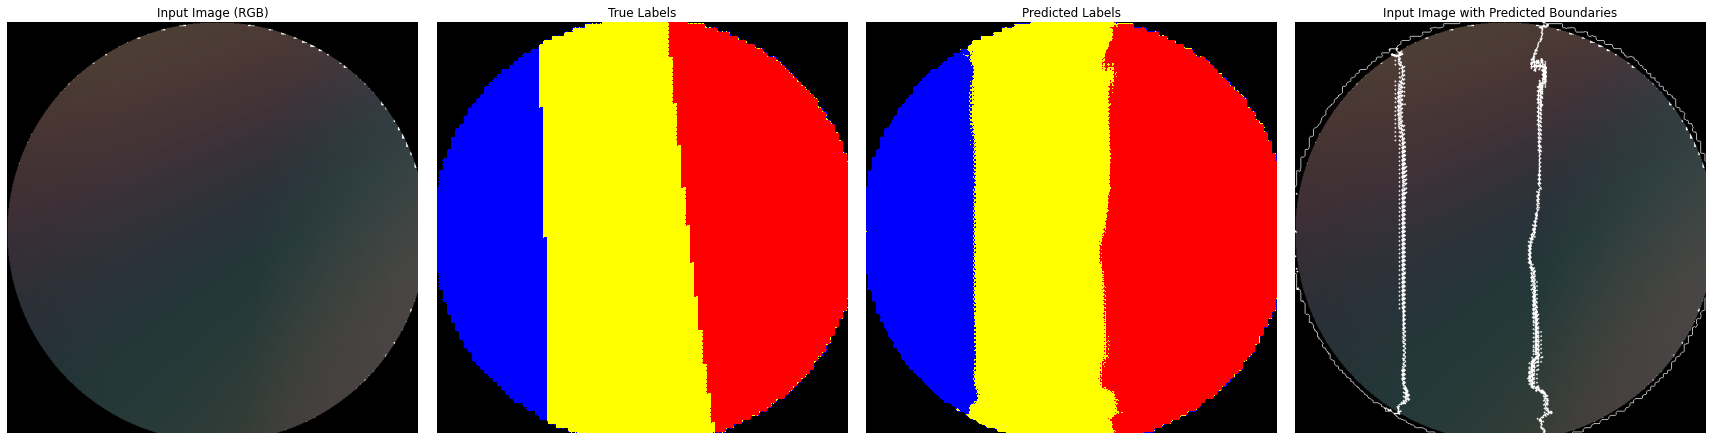

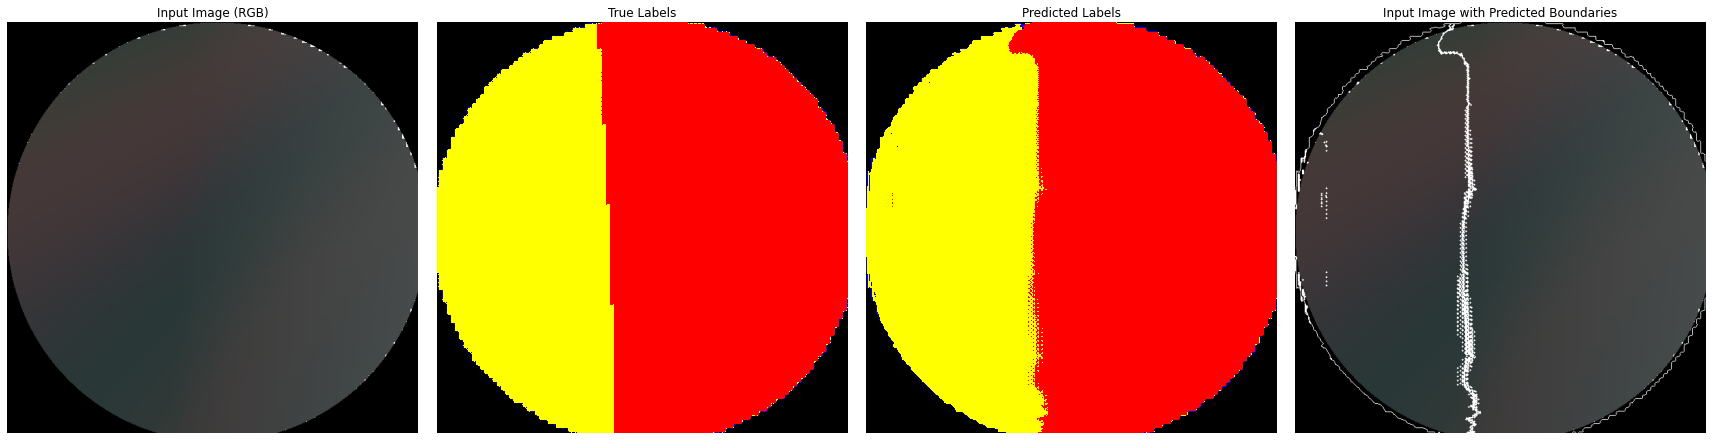

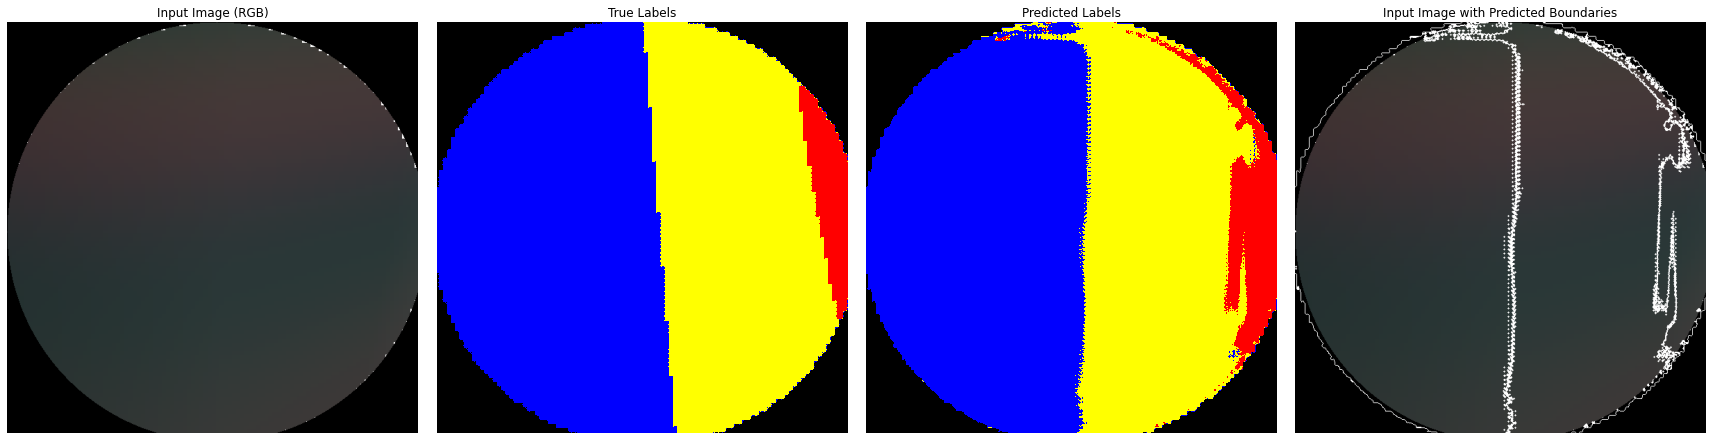

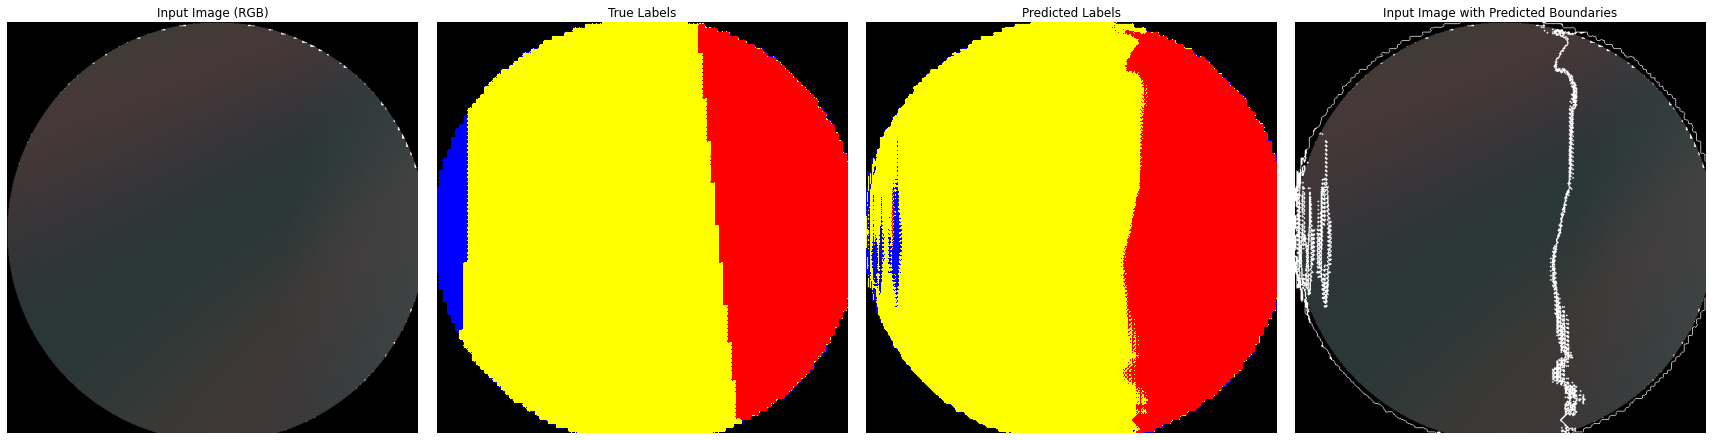

1/1 [==============================] - 0s 34ms/step


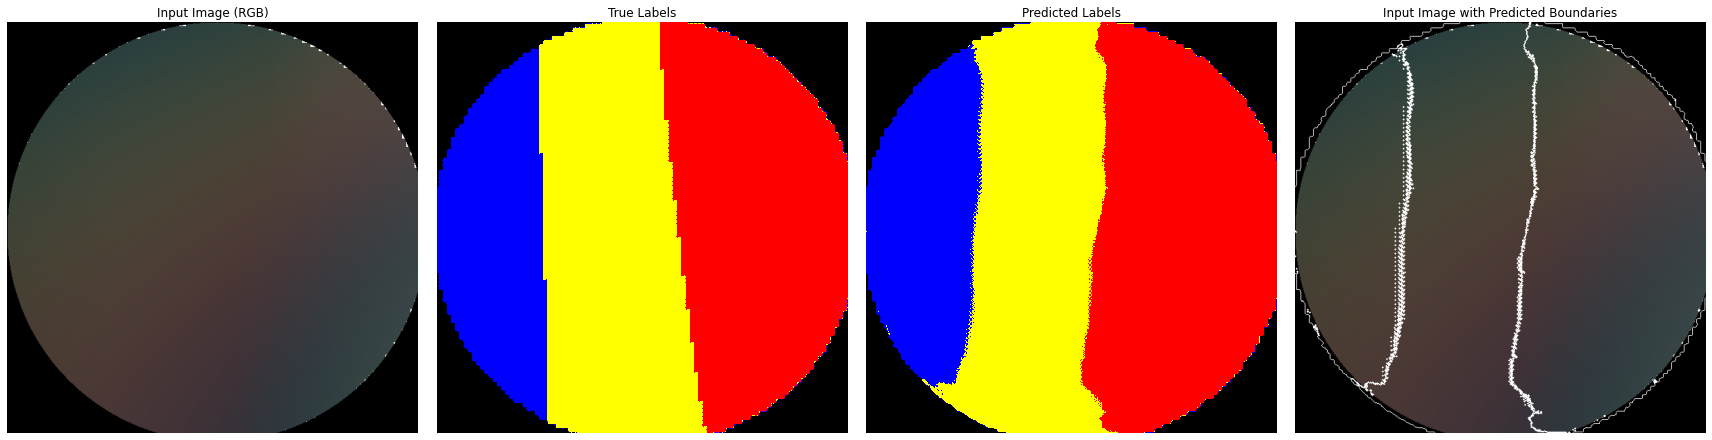

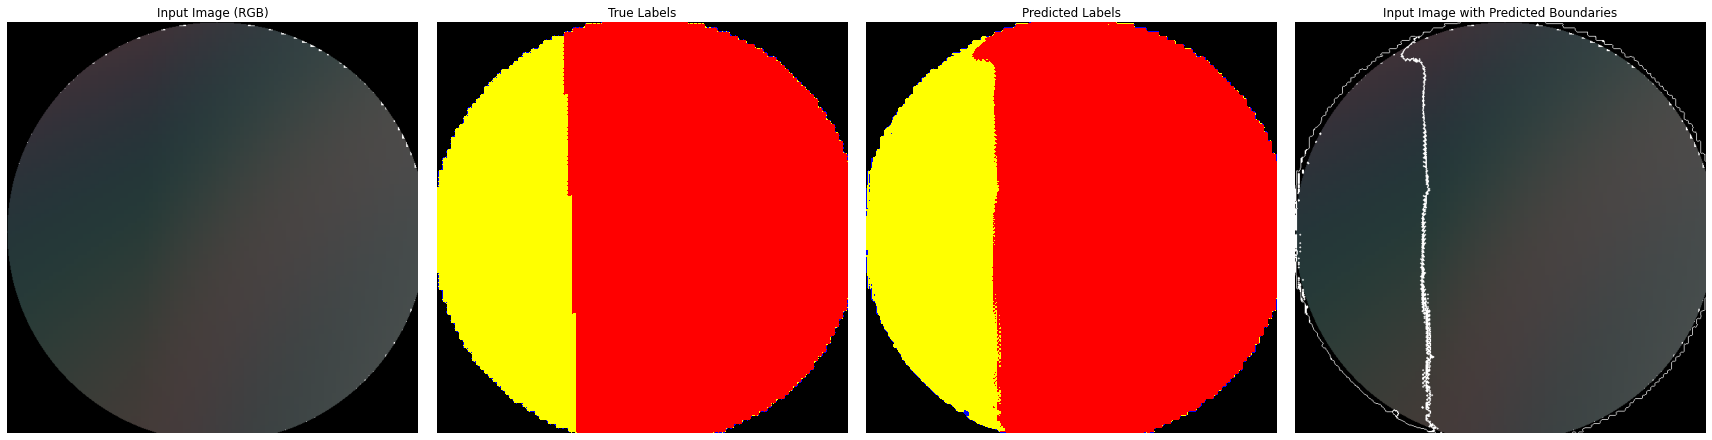

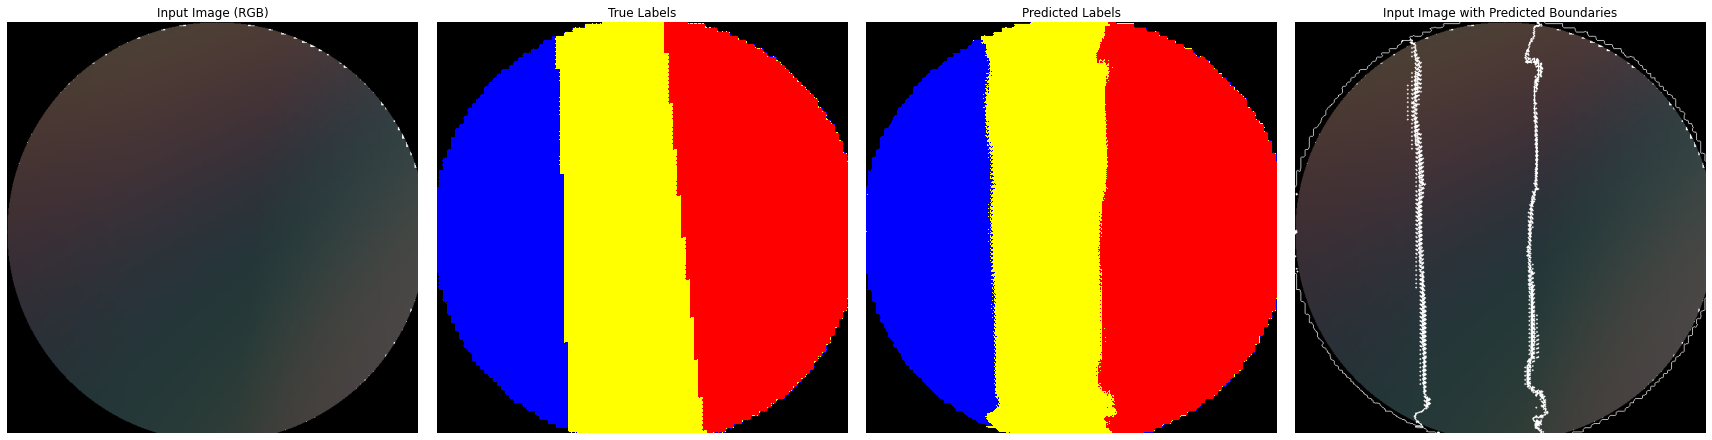

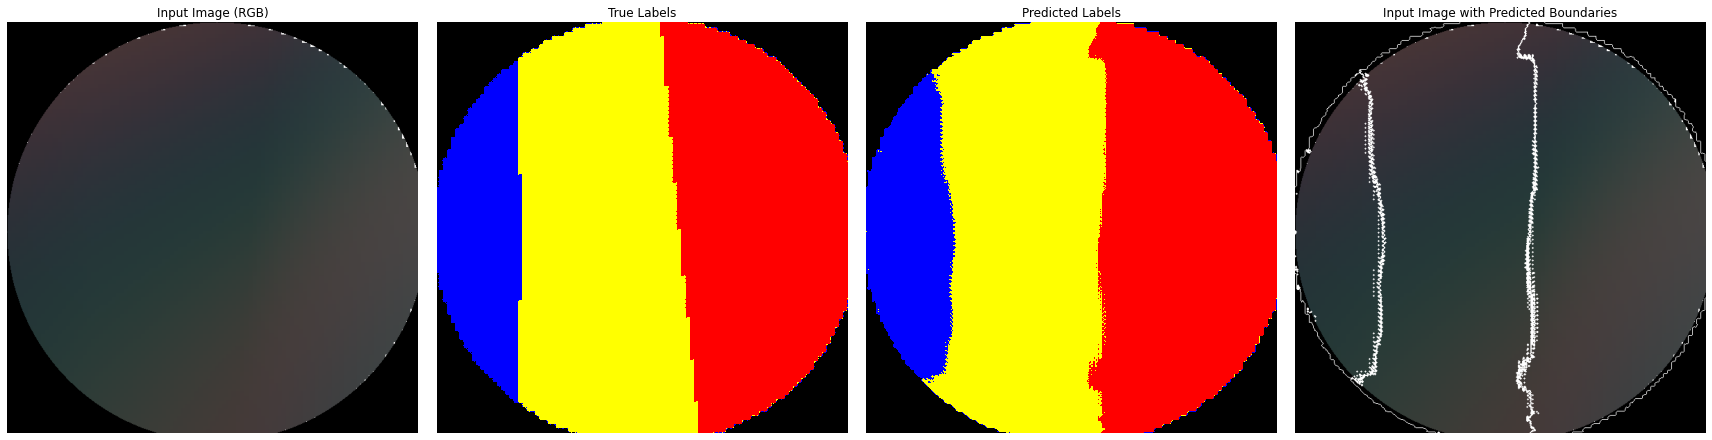

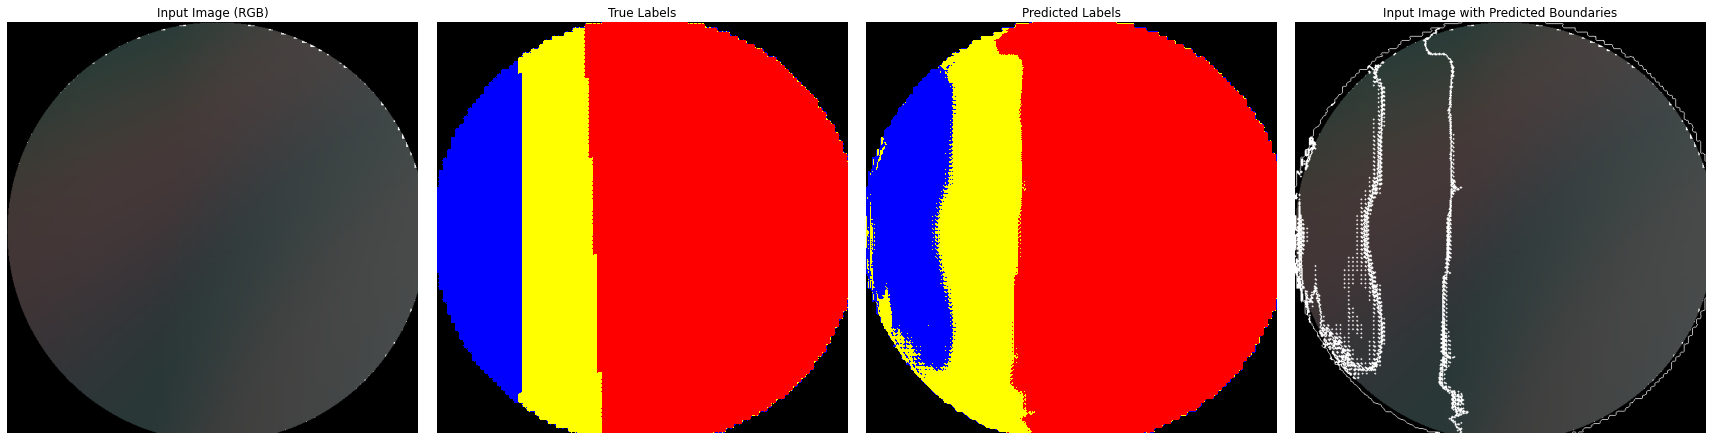

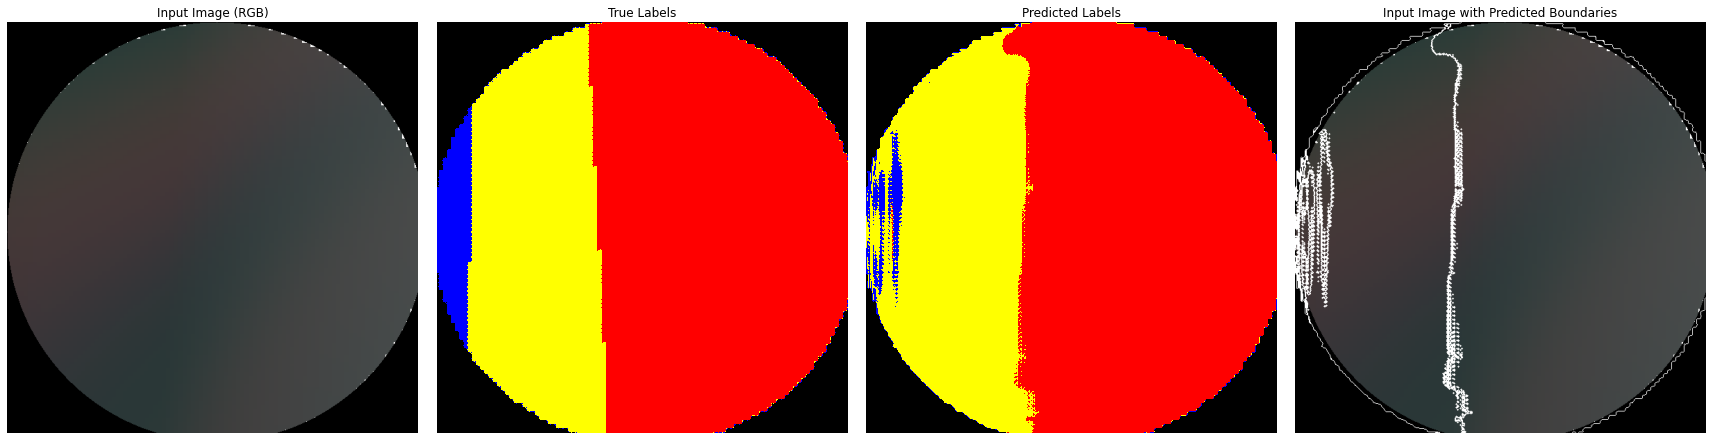

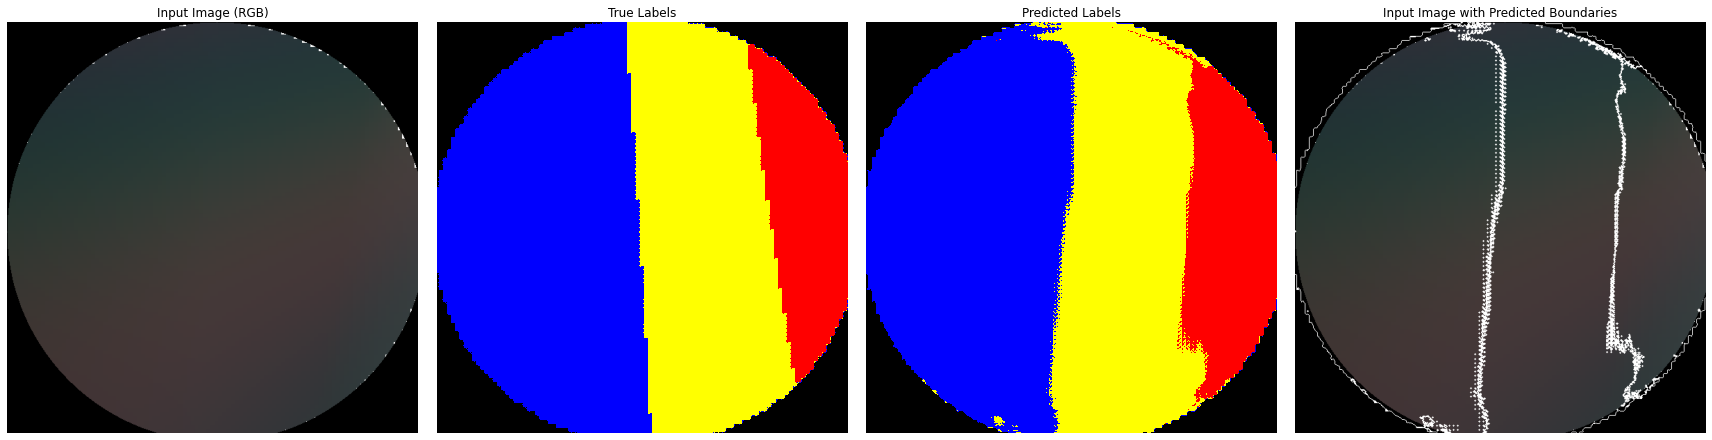

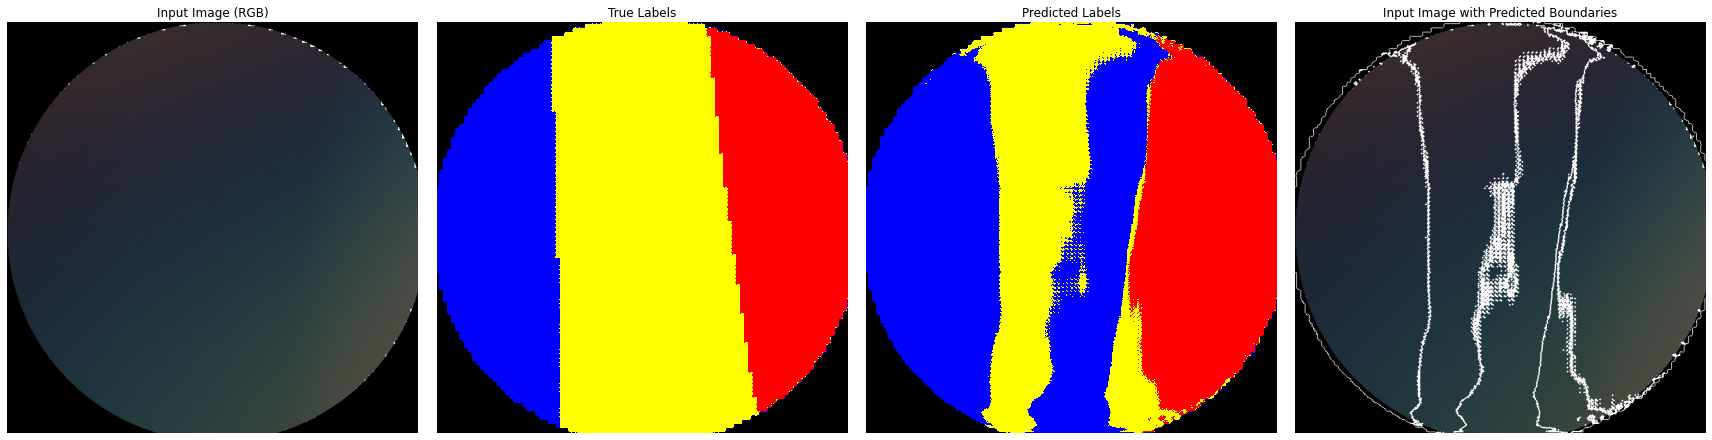

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from skimage.segmentation import find_boundaries

# Evaluate the model on the test set and calculate accuracy
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test Loss: {test_loss}, Test Accuracy: {test_acc}')

# Define a custom color map for labels
# 0 - Background (Black)
# 1 - Blue
# 2 - Yellow
# 3 - Red

custom_cmap = ListedColormap(['black', 'blue', 'yellow', 'red'])

# Function to visualize predictions with custom colors and boundaries
def visualize_predictions_with_boundaries(generator, model, num_samples=5):
    """
    Visualize model predictions on the test set with custom colors and boundaries.
    
    Parameters:
        generator (DataGenerator): Test set data generator.
        model (tf.keras.Model): Trained model.
        num_samples (int): Number of samples to visualize.
    """
    # Ensure num_samples does not exceed the number of available batches
    total_batches = len(generator)
    samples_per_batch = generator.batch_size
    max_samples = total_batches * samples_per_batch
    
    if num_samples > max_samples:
        print(f"Requested {num_samples} samples, but only {max_samples} are available.")
        num_samples = max_samples
    
    samples_visualized = 0
    
    for batch_idx in range(total_batches):
        X_batch, y_true_batch = generator[batch_idx]
        y_pred_batch = model.predict(X_batch)
        
        for i in range(X_batch.shape[0]):
            if samples_visualized >= num_samples:
                return
            
            input_image = X_batch[i]  # Input image
            y_true = np.argmax(y_true_batch[i], axis=-1)  # True labels
            y_pred = np.argmax(y_pred_batch[i], axis=-1)  # Predicted labels
            
            # Find boundaries in predicted labels
            boundaries = find_boundaries(y_pred, mode='inner')
            
            # Create a copy of the input image to overlay boundaries
            input_with_boundaries = input_image[..., :3].astype(np.uint8).copy()
            
            # Overlay boundaries in white
            input_with_boundaries[boundaries] = [255, 255, 255]  # White color
            
            # Create a figure with four subplots
            fig, axes = plt.subplots(1, 4, figsize=(24, 6))
            
            # Display the input image
            axes[0].imshow(input_image[..., :3].astype(np.uint8))
            axes[0].set_title("Input Image (RGB)")
            axes[0].axis('off')
            
            # Display the true labels with custom color map
            axes[1].imshow(y_true, cmap=custom_cmap, vmin=0, vmax=num_classes-1)
            axes[1].set_title("True Labels")
            axes[1].axis('off')
            
            # Display the predicted labels with custom color map
            axes[2].imshow(y_pred, cmap=custom_cmap, vmin=0, vmax=num_classes-1)
            axes[2].set_title("Predicted Labels")
            axes[2].axis('off')
            
            # Display the input image with boundaries
            axes[3].imshow(input_with_boundaries)
            axes[3].set_title("Input Image with Predicted Boundaries")
            axes[3].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            samples_visualized += 1

# Visualize some predictions on the test set with custom colors and boundaries
visualize_predictions_with_boundaries(test_generator, model, num_samples=40)
